<a href="https://colab.research.google.com/github/kavinkumarManielayaperumal/Toy-Model-for-Gaussian-Mixture-in-Traffic-Scenario-Group-Project./blob/main_toy/model_that_runs_in_core_features_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  ***Necessary libraries***

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive




# ***Standardize data***

In [ ]:


# Define the file path for the input CSV file
file_path = r'F:\gaussian mixture\for_data\highD-dataset-v1.0\data\01_tracks.csv'

# Load the dataset
data = pd.read_csv(file_path)

# Columns to standardize
columns_to_standardize = ['x', 'y', 'xVelocity', 'yVelocity', 'xAcceleration', 'yAcceleration']

# Compute mean and standard deviation for the selected columns
mean_std = data[columns_to_standardize].agg(['mean', 'std'])

# Standardize the selected columns using Z-score formula
data_standardized = data.copy()
for col in columns_to_standardize:
    data_standardized[col] = (data[col] - mean_std.loc['mean', col]) / mean_std.loc['std', col]

# Print the first few rows of the standardized dataset (for verification)
print(data_standardized.head())

# Define the output directory and file path
output_folder = r'F:\gaussian mixture\standardized_data'
output_file_path = os.path.join(output_folder, 'standardized_01_tracks.csv')

# Create the folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created new folder: {output_folder}")

# Save the standardized dataset to a new CSV file
data_standardized.to_csv(output_file_path, index=False)
print(f"Standardized data saved to: {output_file_path}")


# ***Model***


*   Initialization

*   Define E-step (Expectation)
*   Define M-step (Maximization)


*   Combine into EM Algorithm


*   Assign Clusters and Visualize






In [4]:
# Load Standardized File (Before Initialization) for the single file
# Load the standardized file
drive.mount('/content/drive')
file_path =r"/content/drive/My Drive/for data/standardized_01(core features)_tracks.csv"
data = pd.read_csv(file_path)
# Convert to NumPy array (optional, if not working with pandas)
X = data.values  # X is the standardized data (n_samples, n_features)

Mounted at /content/drive


## ***Initialization***

In [5]:
import numpy as np

# Function to initialize the parameters
def initialize_parameters(X, num_clusters):
    """
    Initializes the parameters for GMM.

    Parameters:
        X (numpy.ndarray): The dataset of shape (n_samples, n_features).
        num_clusters (int): The number of clusters (Gaussian components).

    Returns:
        means (numpy.ndarray): Initial means for each cluster of shape (num_clusters, n_features).
        covariances (list of numpy.ndarray): Initial covariance matrices for each cluster.
        weights (numpy.ndarray): Initial weights for each cluster of shape (num_clusters,).
    """
    np.random.seed(42)  # For reproducibility
    n_samples, n_features = X.shape

    # Step 1: Initialize means by randomly sampling data points
    initial_means = X[np.random.choice(n_samples, num_clusters, replace=False)]

    # Step 2: Initialize covariances as identity matrices
    initial_covariances = [np.eye(n_features) for _ in range(num_clusters)]

    # Step 3: Initialize weights equally
    initial_weights =6* np.ones(num_clusters) / num_clusters

    return initial_means, initial_covariances, initial_weights

# Example usage:
# Assuming `data_standardized` is your standardized dataset
num_clusters = 6  # Number of clusters (e.g., Left, Straight, Right)
means, covariances, weights = initialize_parameters(X, num_clusters)

# Print the initialized parameters
print("Initial Means:\n", means)
print("\nInitial Covariances:\n", covariances)
print("\nInitial Weights:\n", weights)


Initial Means:
 [[ 1.72535113  1.35343136  0.89109339  0.17491752  0.01779814  0.39454963]
 [-1.47128414 -1.16196731 -0.82194716 -0.87524276 -0.21849952  0.15073248]
 [-0.02688552  1.38934332  0.82262444  0.00910274 -0.65733803 -0.58071897]
 [-1.57426654 -0.46090337 -0.97402724  0.06437433 -1.39998781 -0.33690182]
 [ 1.59097061 -0.52023618 -0.76006176  0.11964592 -0.42104037 -0.21499324]
 [ 0.28214701 -1.0729681  -0.86638615  0.61709027  0.6929343  -0.09308467]]

Initial Covariances:
 [array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.]]), array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.]]), array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0.

# ***Define E-step (Expectation)***

In [6]:
# E-step: Calculate posterior probabilities (responsibilities)
def e_step(X, means, covariances, weights, num_clusters):
    n_samples, n_features = X.shape
    responsibilities = np.zeros((n_samples, num_clusters))

    for k in range(num_clusters):
        diff = X - means[k]
        cov_inv = np.linalg.inv(covariances[k])
        exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
        normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariances[k]))
        responsibilities[:, k] = weights[k] * np.exp(exponent) / normalization

    # Normalize responsibilities
    responsibilities = responsibilities / responsibilities.sum(axis=1, keepdims=True)
    return responsibilities


# ***Define M-step (Maximization)***

In [7]:
# M-step: Update parameters
def m_step(X, responsibilities, num_clusters):
    n_samples, n_features = X.shape
    weights = responsibilities.sum(axis=0) / n_samples
    means = np.zeros((num_clusters, n_features))
    covariances = []

    for k in range(num_clusters):
        resp = responsibilities[:, k]
        total_resp = resp.sum()

        # Update means
        means[k] = np.sum(resp[:, np.newaxis] * X, axis=0) / total_resp

        # Update covariances
        diff = X - means[k]
        cov = (resp[:, np.newaxis] * diff).T @ diff / total_resp
        covariances.append(cov)

    return means, covariances, weights





# ***Combine into EM Algorithm***




In [8]:
def run_em_algorithm(X, num_clusters, max_iter=100, tol=1e-6, visualize_steps=[0, 30, 60, 90]):
    """
    Run the EM algorithm to fit a Gaussian Mixture Model and store parameters for visualization.

    Parameters:
        X (numpy.ndarray): The dataset of shape (n_samples, n_features).
        num_clusters (int): The number of clusters (Gaussian components).
        max_iter (int): Maximum number of iterations for the EM algorithm.
        tol (float): Tolerance for convergence.
        visualize_steps (list): Iterations to save parameters for visualization.

    Returns:
        means (numpy.ndarray): Final means for each cluster.
        covariances (list of numpy.ndarray): Final covariance matrices for each cluster.
        weights (numpy.ndarray): Final weights for each cluster.
        responsibilities (numpy.ndarray): Final posterior probabilities for each data point.
        means_list (list): List of means at specific iterations for visualization.
        covariances_list (list): List of covariance matrices at specific iterations for visualization.
        weights_list (list): List of weights at specific iterations for visualization.
    """
    # Step 1: Initialize parameters
    means, covariances, weights = initialize_parameters(X, num_clusters)
    log_likelihood_old = 0  # Initial log-likelihood

    # Lists to store parameters for visualization
    means_list = []
    covariances_list = []
    weights_list = []
    saved_iterations = []


    for iteration in range(max_iter):
        # Step 2: E-step - Calculate posterior probabilities (responsibilities)
        responsibilities = e_step(X, means, covariances, weights, num_clusters)

        # Step 3: M-step - Update parameters
        means, covariances, weights = m_step(X, responsibilities, num_clusters)

        # Save parameters for visualization
        if  iteration % 10 == 0 or iteration == 0:
            means_list.append(means.copy())
            covariances_list.append([cov.copy() for cov in covariances])
            weights_list.append(weights.copy())
            saved_iterations.append(iteration)  # Save the iteration number

        # Step 4: Compute log-likelihood
        log_likelihood = np.sum(
            np.log(
                np.sum(
                    [
                        weights[k] * multivariate_gaussian(X, means[k], covariances[k])
                        for k in range(num_clusters)
                    ],
                    axis=0,
                ) + 1e-10  # To prevent log(0)
            )
        )

        # Print log-likelihood for debugging
        print(f"Iteration {iteration}, Log-likelihood: {log_likelihood}")

        # Check for convergence
        if np.abs(log_likelihood - log_likelihood_old) < tol:
            print(f"Converged at iteration {iteration}")
            break
        log_likelihood_old = log_likelihood

    return means, covariances, weights, responsibilities, means_list, covariances_list, weights_list, saved_iterations


# Multivariate Gaussian Function (unchanged)
def multivariate_gaussian(X, mean, covariance):
    n_features = X.shape[1]
    diff = X - mean
    cov_inv = np.linalg.inv(covariance)
    exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
    normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariance))
    return np.exp(exponent) / normalization
    # Number of clusters for your project (e.g., Left, Straight, Right)




In [9]:
# Number of clusters for your project (e.g., Left, Straight, Right)
num_clusters = 6
max_iter = 100
tol = 1e-6

# Specify iterations for visualization
visualize_steps = [0, 30,60,90]

# Run the EM algorithm with visualization steps
final_means, final_covariances, final_weights, final_responsibilities, means_list, covariances_list, weights_list,saved_iterations = run_em_algorithm(
    X, num_clusters=6, max_iter=100, tol=1e-6, visualize_steps=visualize_steps)


# Print final parameters for verification
print("\nFinal Means:\n", final_means)
print("\nFinal Covariances:\n", final_covariances)
print("\nFinal Weights:\n", final_weights)


Iteration 0, Log-likelihood: -2308223.63666928
Iteration 1, Log-likelihood: -1953800.0444081188
Iteration 2, Log-likelihood: -1911403.0104063288
Iteration 3, Log-likelihood: -1886274.46962595
Iteration 4, Log-likelihood: -1866733.6782135025
Iteration 5, Log-likelihood: -1849617.4193152804
Iteration 6, Log-likelihood: -1825710.8025956796
Iteration 7, Log-likelihood: -1803692.8987393298
Iteration 8, Log-likelihood: -1789738.4648805116
Iteration 9, Log-likelihood: -1782745.9587147064
Iteration 10, Log-likelihood: -1779450.691527192
Iteration 11, Log-likelihood: -1777487.8568418892
Iteration 12, Log-likelihood: -1775982.78100044
Iteration 13, Log-likelihood: -1774614.4510716384
Iteration 14, Log-likelihood: -1773134.069807147
Iteration 15, Log-likelihood: -1771376.0520009934
Iteration 16, Log-likelihood: -1769243.1529658323
Iteration 17, Log-likelihood: -1766707.6870288525
Iteration 18, Log-likelihood: -1763861.0525931849
Iteration 19, Log-likelihood: -1760926.8682830434
Iteration 20, Log-

#         ***Assign Clusters and Visualize***

In [10]:
print(f"Length of means_list: {len(means_list)}")
print(f"Length of covariances_list: {len(covariances_list)}")
print(f"Length of weights_list: {len(weights_list)}")
print(f"Visualize steps: {saved_iterations}")


Length of means_list: 8
Length of covariances_list: 8
Length of weights_list: 8
Visualize steps: [0, 10, 20, 30, 40, 50, 60, 70]


In [11]:
print(f"Length of means_list: {len(means_list)}")
#saved_iterations = list(range(0, len(means_list)))  # Automatically set visualize steps
print(f"Adjusted visualize_steps: {saved_iterations}")


Length of means_list: 8
Adjusted visualize_steps: [0, 10, 20, 30, 40, 50, 60, 70]


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def visualize_gmm_progression(X, means_list, covariances_list, weights_list,saved_iterations, feature_idx1=0, feature_idx2=1):
    """
    Visualizes GMM clustering progression for specified iterations.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        weights_list (list): List of weights at specified iterations.
        visualize_steps (list): Iterations for which to visualize the clustering.
        feature_idx1 (int): Index of the first feature to plot (default: 0).
        feature_idx2 (int): Index of the second feature to plot (default: 1).
    """
    x_range = np.linspace(np.min(X[:, feature_idx1]), np.max(X[:, feature_idx1]), 500)
    y_range = np.linspace(np.min(X[:, feature_idx2]), np.max(X[:, feature_idx2]), 500)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue
        plt.figure(figsize=(8, 6))

        # Scatter plot of the data points
        plt.scatter(X[:, feature_idx1], X[:, feature_idx2], c='gray', alpha=0.5, s=10, label="Data Points")

        # Plot Gaussian distributions
        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx]
            covariance = covariances_list[step_idx][cluster_idx]

            # Extract 2D subspace of the covariance matrix
            sub_covariance = covariance[np.ix_([feature_idx1, feature_idx2], [feature_idx1, feature_idx2])]
            sub_mean = mean[[feature_idx1, feature_idx2]]

            # Plot the Gaussian as an ellipse
            plot_gaussian_ellipse(sub_mean, sub_covariance, label=f"Cluster {cluster_idx + 1}")

        plt.title(f"GMM Clustering at Iteration {iteration}")
        plt.xlabel(f"Feature {feature_idx1 + 1}")
        plt.ylabel(f"Feature {feature_idx2 + 1}")
        plt.legend()
        plt.grid()
        plt.show()


def plot_gaussian_ellipse(mean, cov, label=None):
    """
    Plots a Gaussian as an ellipse.

    Parameters:
        mean (numpy.ndarray): Mean of the Gaussian distribution (2D).
        cov (numpy.ndarray): Covariance matrix of the Gaussian distribution (2x2).
        label (str): Label for the cluster.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    # Width, height, and angle of the ellipse
    width, height = 2 * np.sqrt(eigenvalues)
    angle = np.arctan2(*eigenvectors[:, 0][::-1]) * (180 / np.pi)

    # Create the ellipse
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='black', facecolor='none', lw=2, label=label)
    plt.gca().add_patch(ellipse)


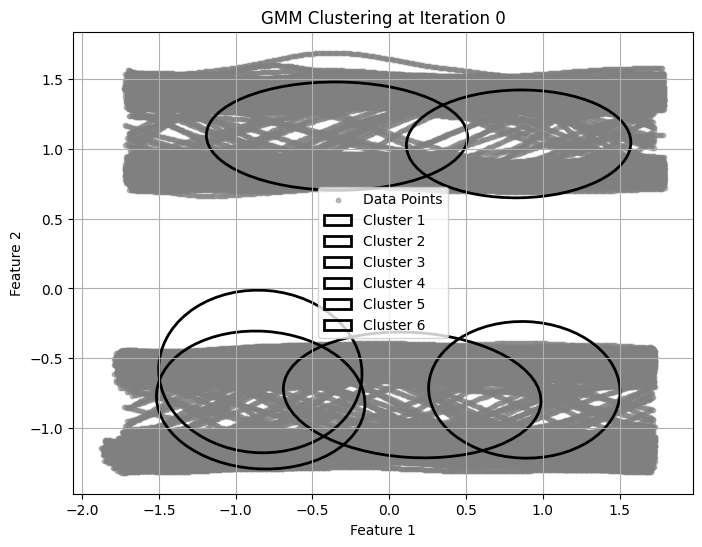

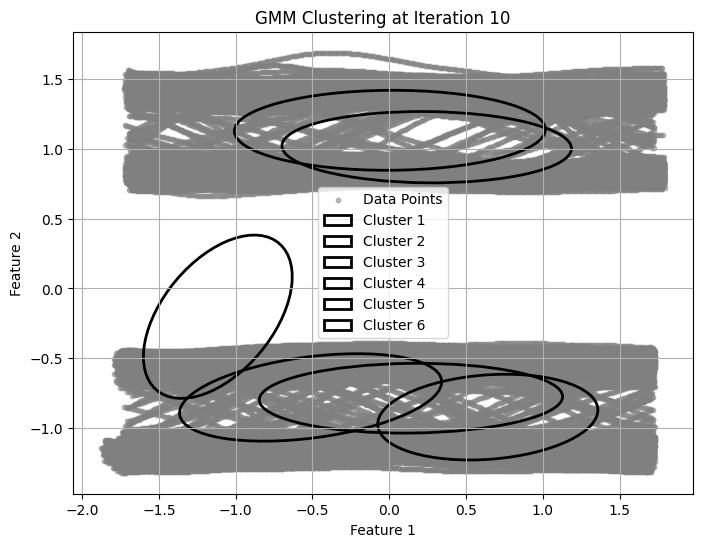

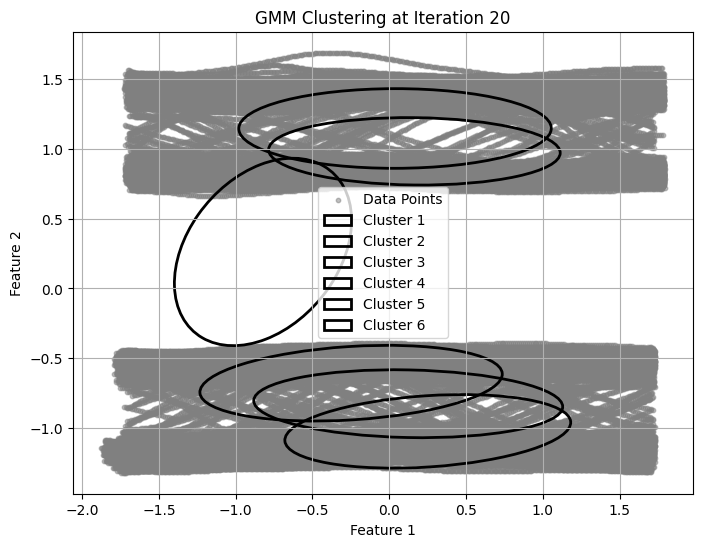

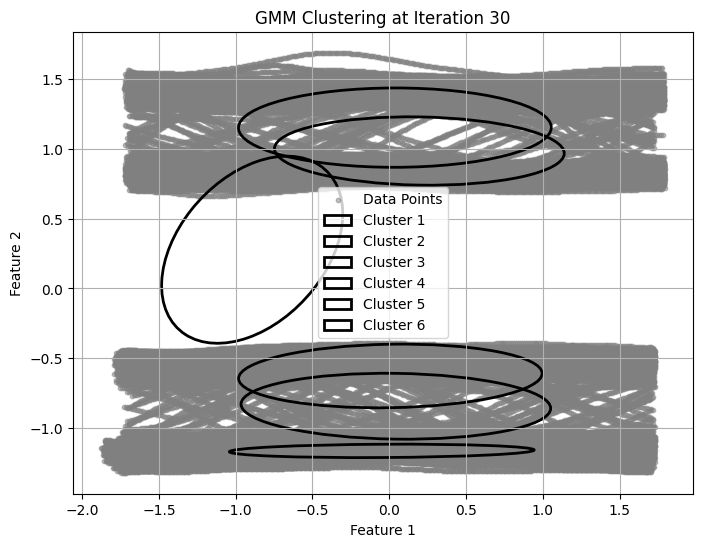

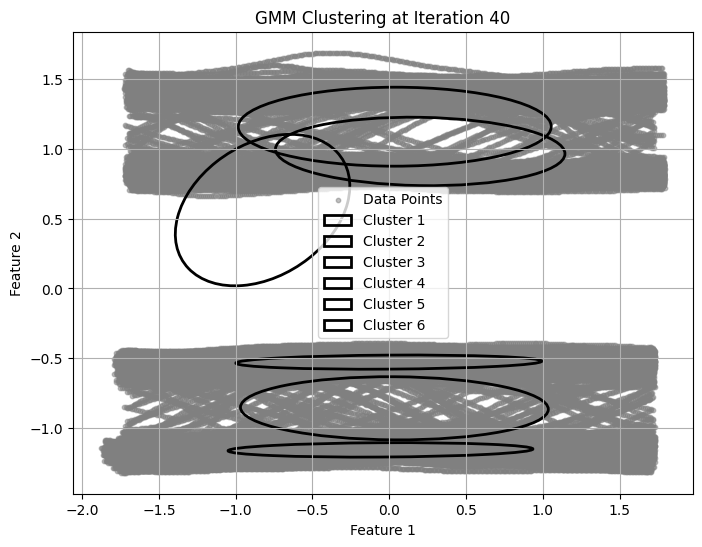

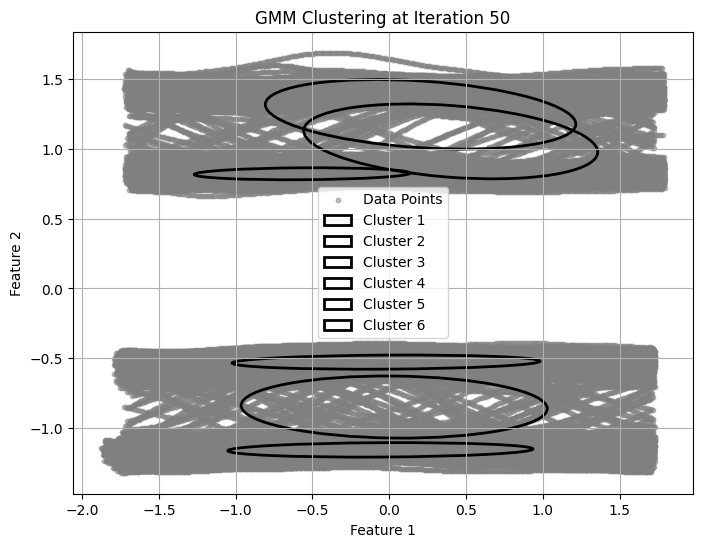

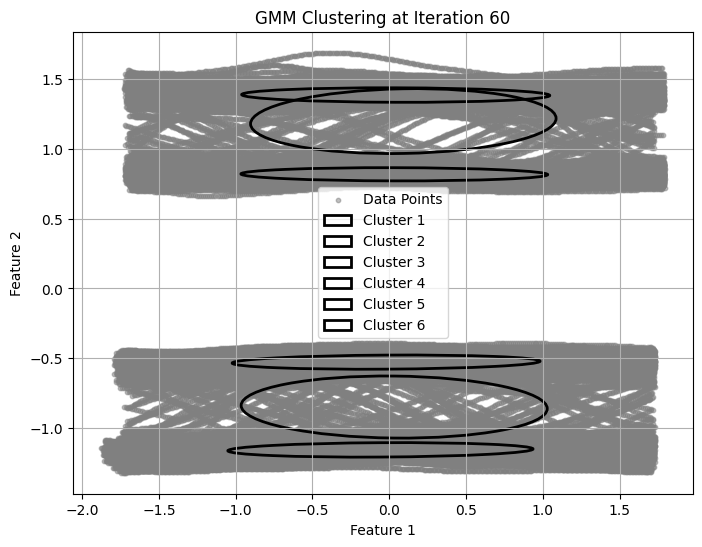

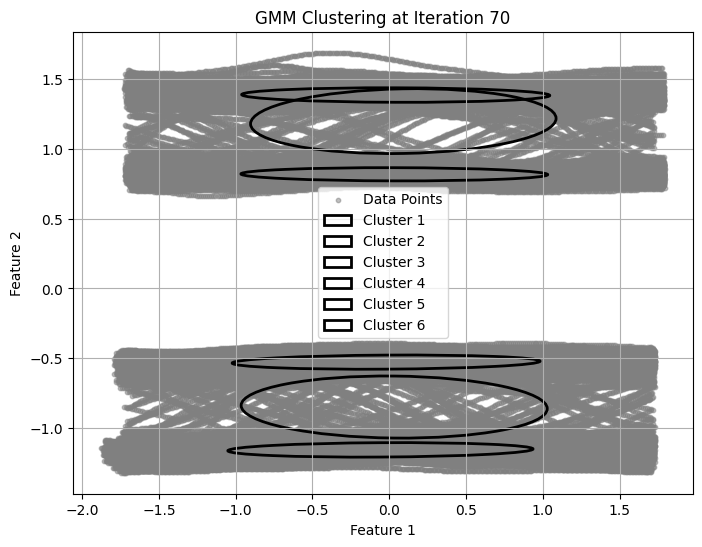

In [13]:
# Call the visualization function
visualize_gmm_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx1=0, feature_idx2=1)


In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def visualize_gmm_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx1=2, feature_idx2=3):
    """
    Visualizes GMM clustering progression for specified iterations.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        weights_list (list): List of weights at specified iterations.
        saved_iterations (list): Iterations for which to visualize the clustering.
        feature_idx1 (int): Index of the first feature to plot (default: xVelocity).
        feature_idx2 (int): Index of the second feature to plot (default: yVelocity).
    """
    x_range = np.linspace(np.min(X[:, feature_idx1]), np.max(X[:, feature_idx1]), 500)
    y_range = np.linspace(np.min(X[:, feature_idx2]), np.max(X[:, feature_idx2]), 500)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue
        plt.figure(figsize=(8, 6))

        # Scatter plot of the data points
        plt.scatter(X[:, feature_idx1], X[:, feature_idx2], c='gray', alpha=0.5, s=10, label="Data Points")

        # Plot Gaussian distributions
        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx]
            covariance = covariances_list[step_idx][cluster_idx]

            # Extract 2D subspace of the covariance matrix
            sub_covariance = covariance[np.ix_([feature_idx1, feature_idx2], [feature_idx1, feature_idx2])]
            sub_mean = mean[[feature_idx1, feature_idx2]]

            # Plot the Gaussian as an ellipse
            plot_gaussian_ellipse(sub_mean, sub_covariance, label=f"Cluster {cluster_idx + 1}")

        plt.title(f"GMM Clustering at Iteration {iteration} (xVelocity vs yVelocity)")
        plt.xlabel("xVelocity")
        plt.ylabel("yVelocity")
        plt.legend()
        plt.grid()
        plt.show()


def plot_gaussian_ellipse(mean, cov, label=None):
    """
    Plots a Gaussian as an ellipse.

    Parameters:
        mean (numpy.ndarray): Mean of the Gaussian distribution (2D).
        cov (numpy.ndarray): Covariance matrix of the Gaussian distribution (2x2).
        label (str): Label for the cluster.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    # Width, height, and angle of the ellipse
    width, height = 2 * np.sqrt(eigenvalues)
    angle = np.arctan2(*eigenvectors[:, 0][::-1]) * (180 / np.pi)

    # Create the ellipse
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='black', facecolor='none', lw=2, label=label)
    plt.gca().add_patch(ellipse)




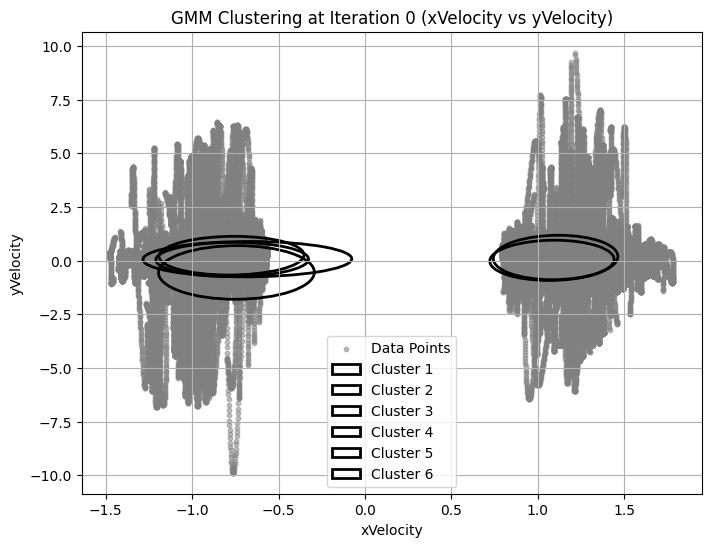

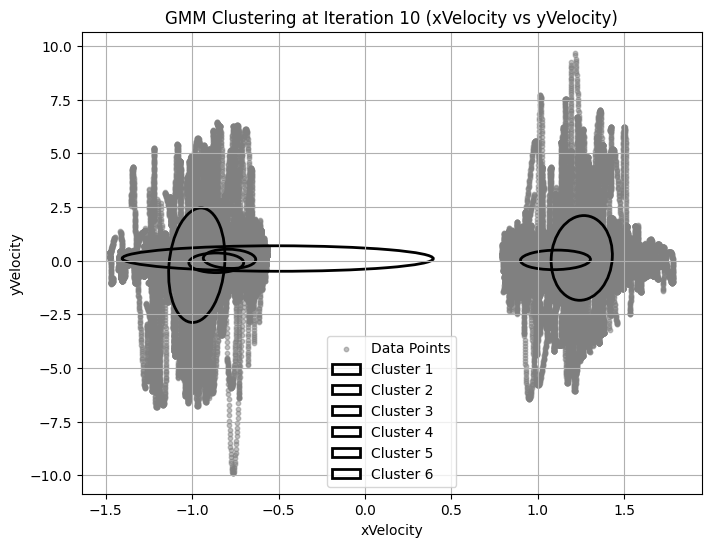

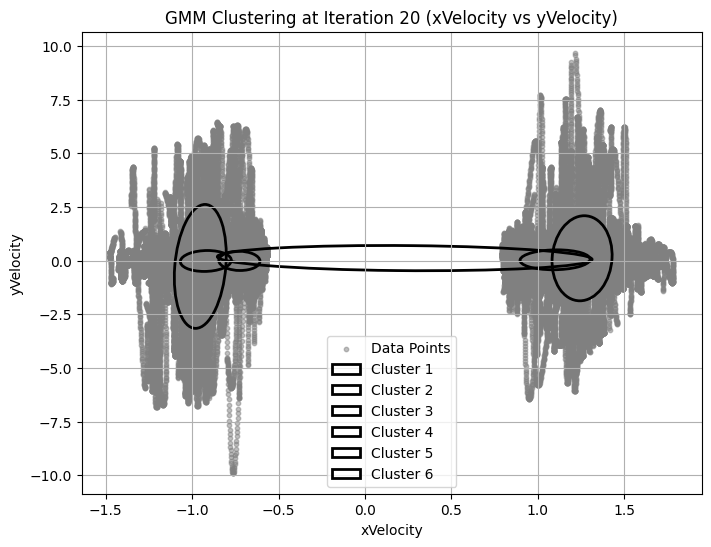

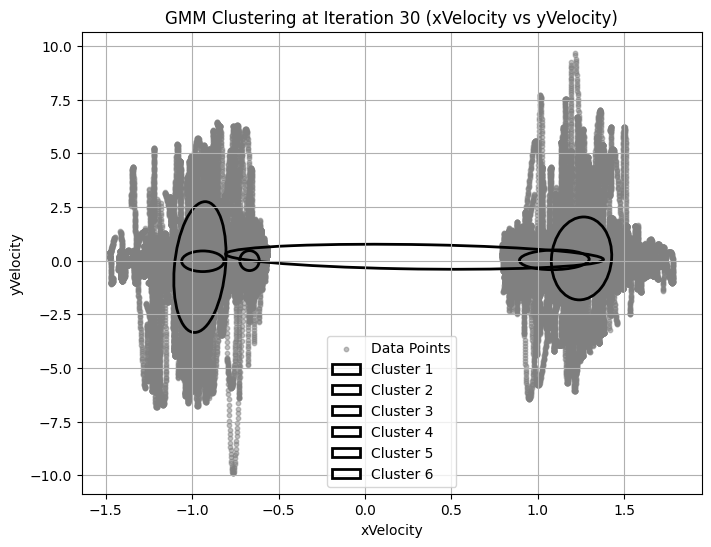

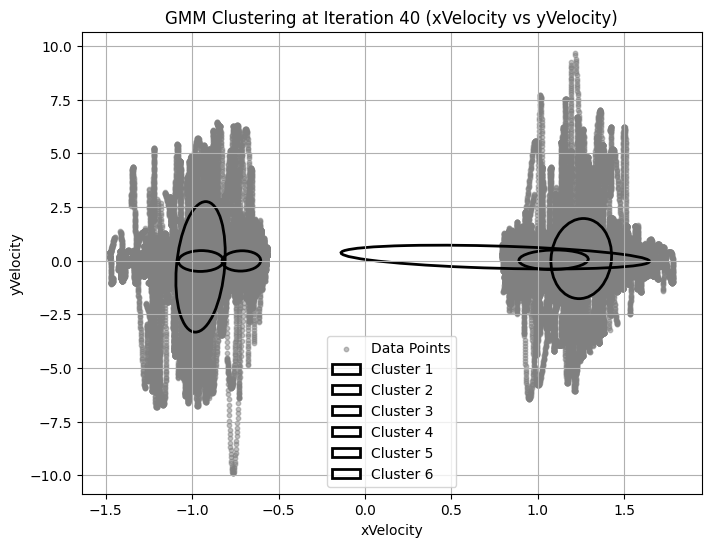

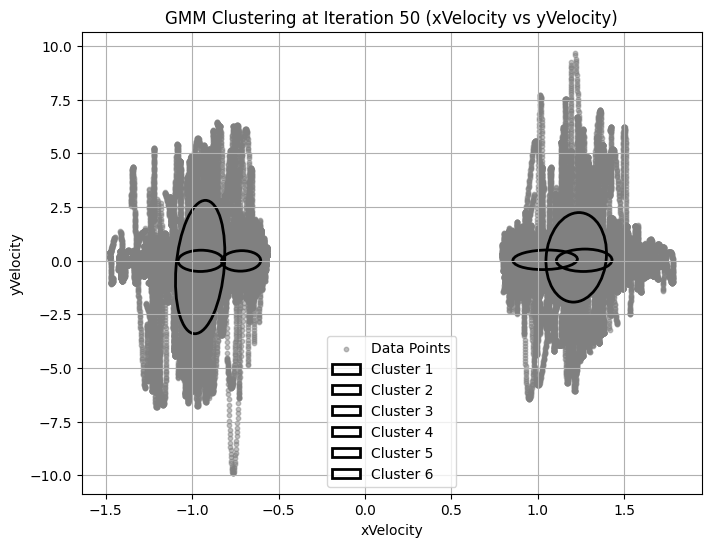

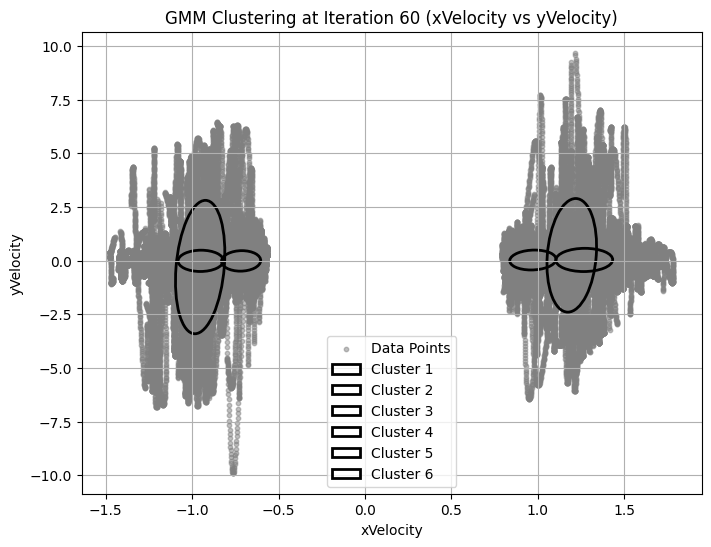

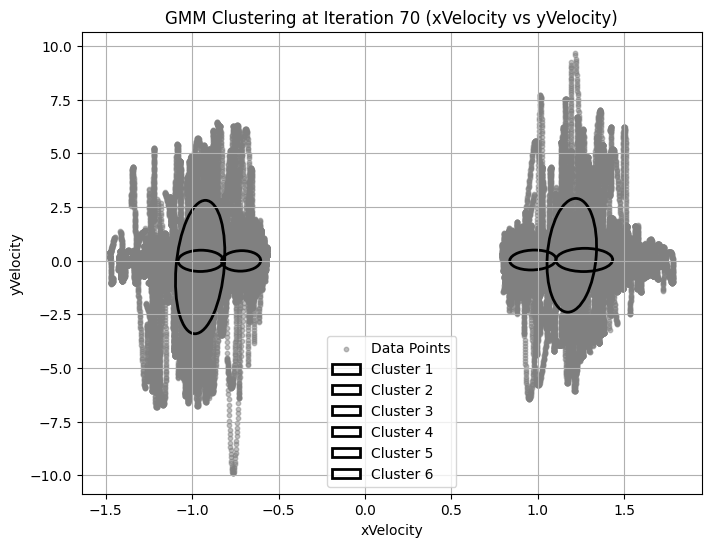

In [15]:

# Call the visualization function
visualize_gmm_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx1=2, feature_idx2=3)

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_all_feature_progressions(X, means_list, covariances_list, weights_list, saved_iterations, feature_names):
    """
    Visualizes GMM clustering progression for all features iteratively.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        weights_list (list): List of weights at specified iterations.
        saved_iterations (list): Iterations for which to visualize the clustering.
        feature_names (list): Names of the features to label the plots.
    """
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        plt.figure(figsize=(20, 12))

        # Loop through all features
        for feature_idx, feature_name in enumerate(feature_names):
            plt.subplot(2, 3, feature_idx + 1)  # Create a grid of 6 subplots (2 rows, 3 columns)

            # Extract data for the specific feature
            feature_data = X[:, feature_idx]

            # Plot data histogram for the feature
            plt.hist(feature_data, bins=30, density=True, alpha=0.5, color="gray", label="Data Distribution")

            # Plot Gaussian curves for each cluster
            for cluster_idx in range(len(means_list[step_idx])):
                mean = means_list[step_idx][cluster_idx][feature_idx]
                variance = covariances_list[step_idx][cluster_idx][feature_idx, feature_idx]
                weight = weights_list[step_idx][cluster_idx]

                # Generate Gaussian curve
                x_range = np.linspace(feature_data.min(), feature_data.max(), 1000)
                gaussian_curve = weight * (1 / (np.sqrt(2 * np.pi * variance))) * np.exp(
                    -0.5 * ((x_range - mean) ** 2) / variance
                )

                # Plot Gaussian curve
                plt.plot(x_range, gaussian_curve, label=f"Cluster {cluster_idx + 1}", lw=2)

            # Title and labels for the subplot
            plt.title(f"{feature_name} - Step {iteration}")
            plt.xlabel(feature_name)
            plt.ylabel("Density")
            plt.legend()
            plt.grid()

        plt.tight_layout()
        plt.show()


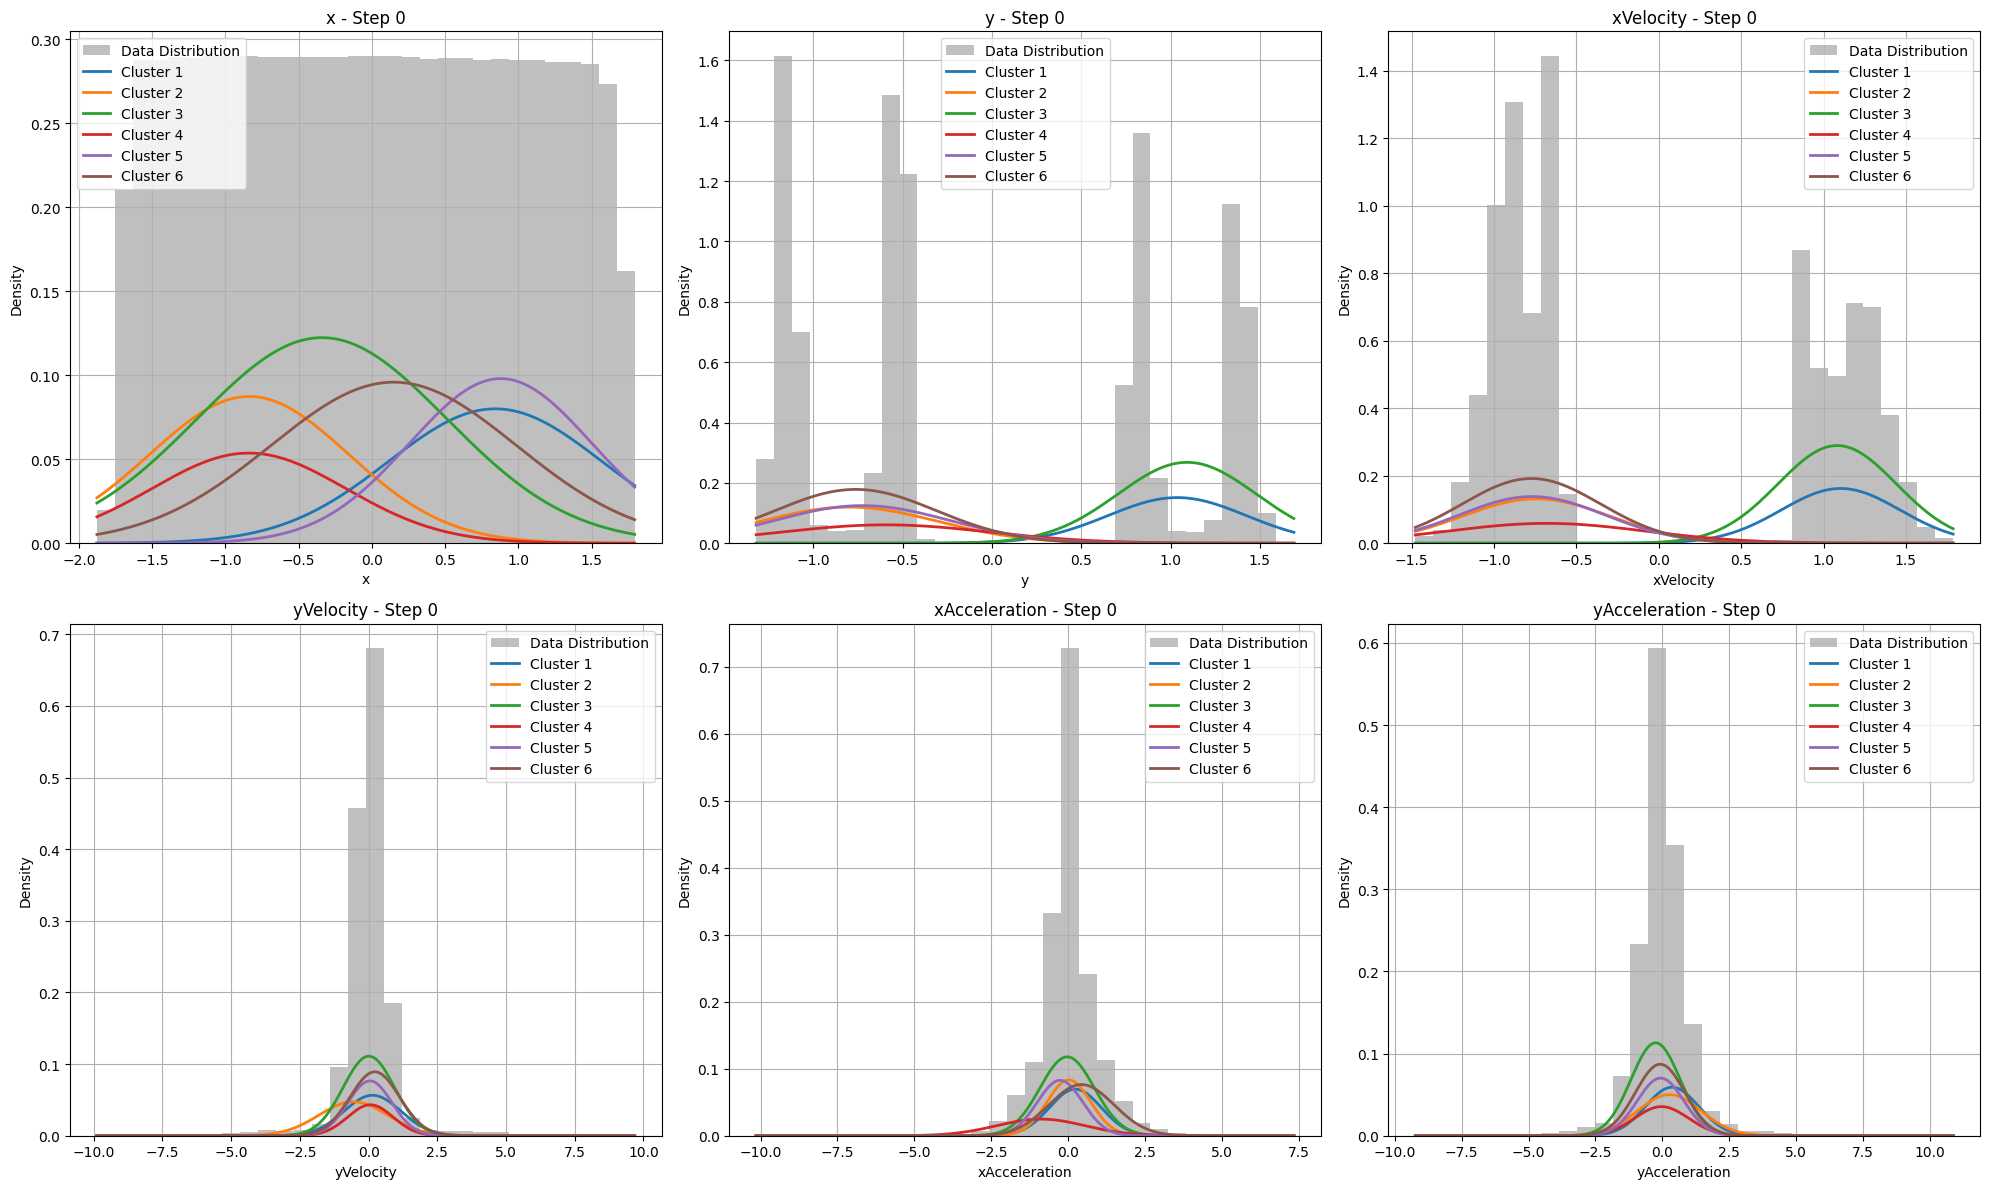

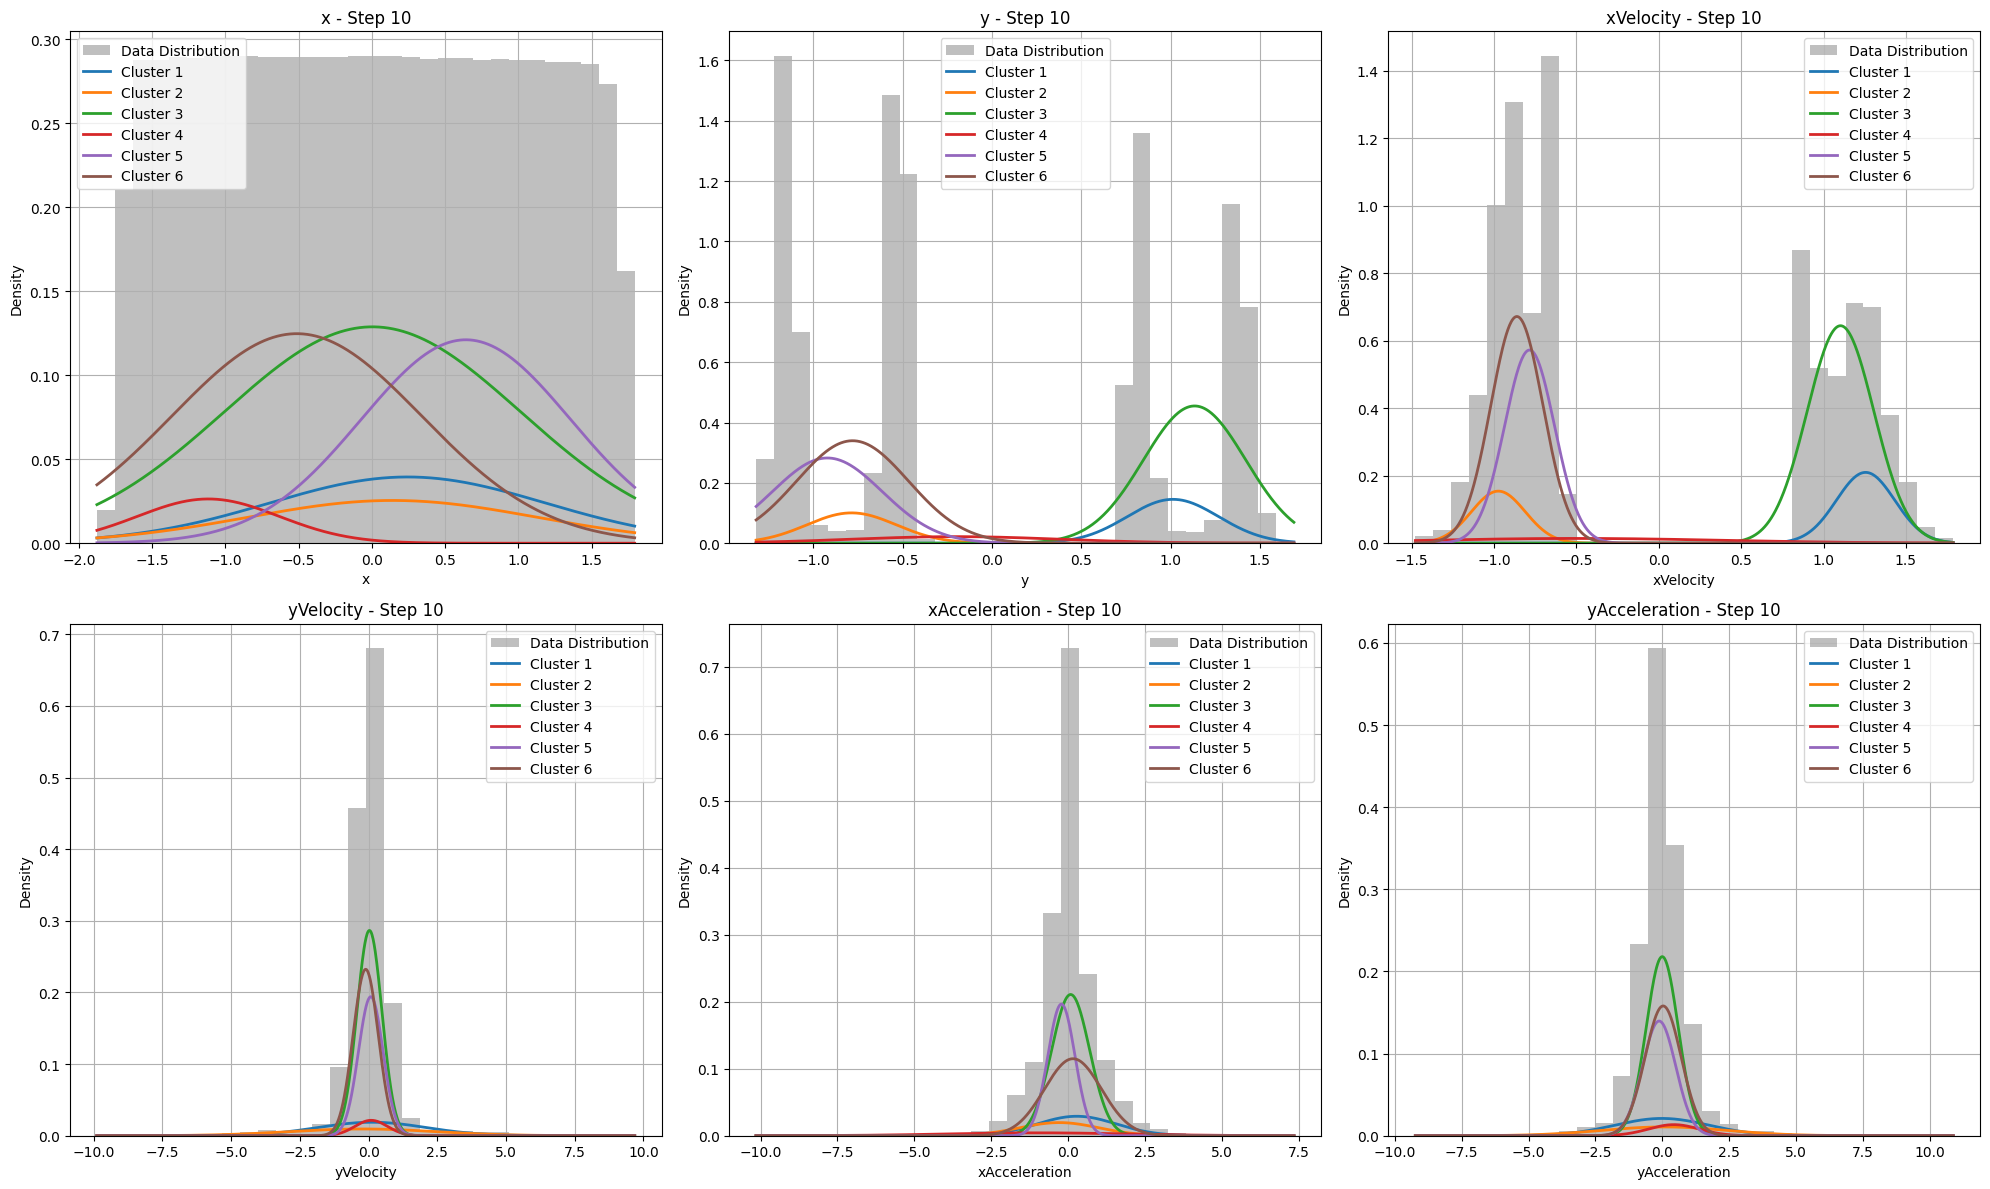

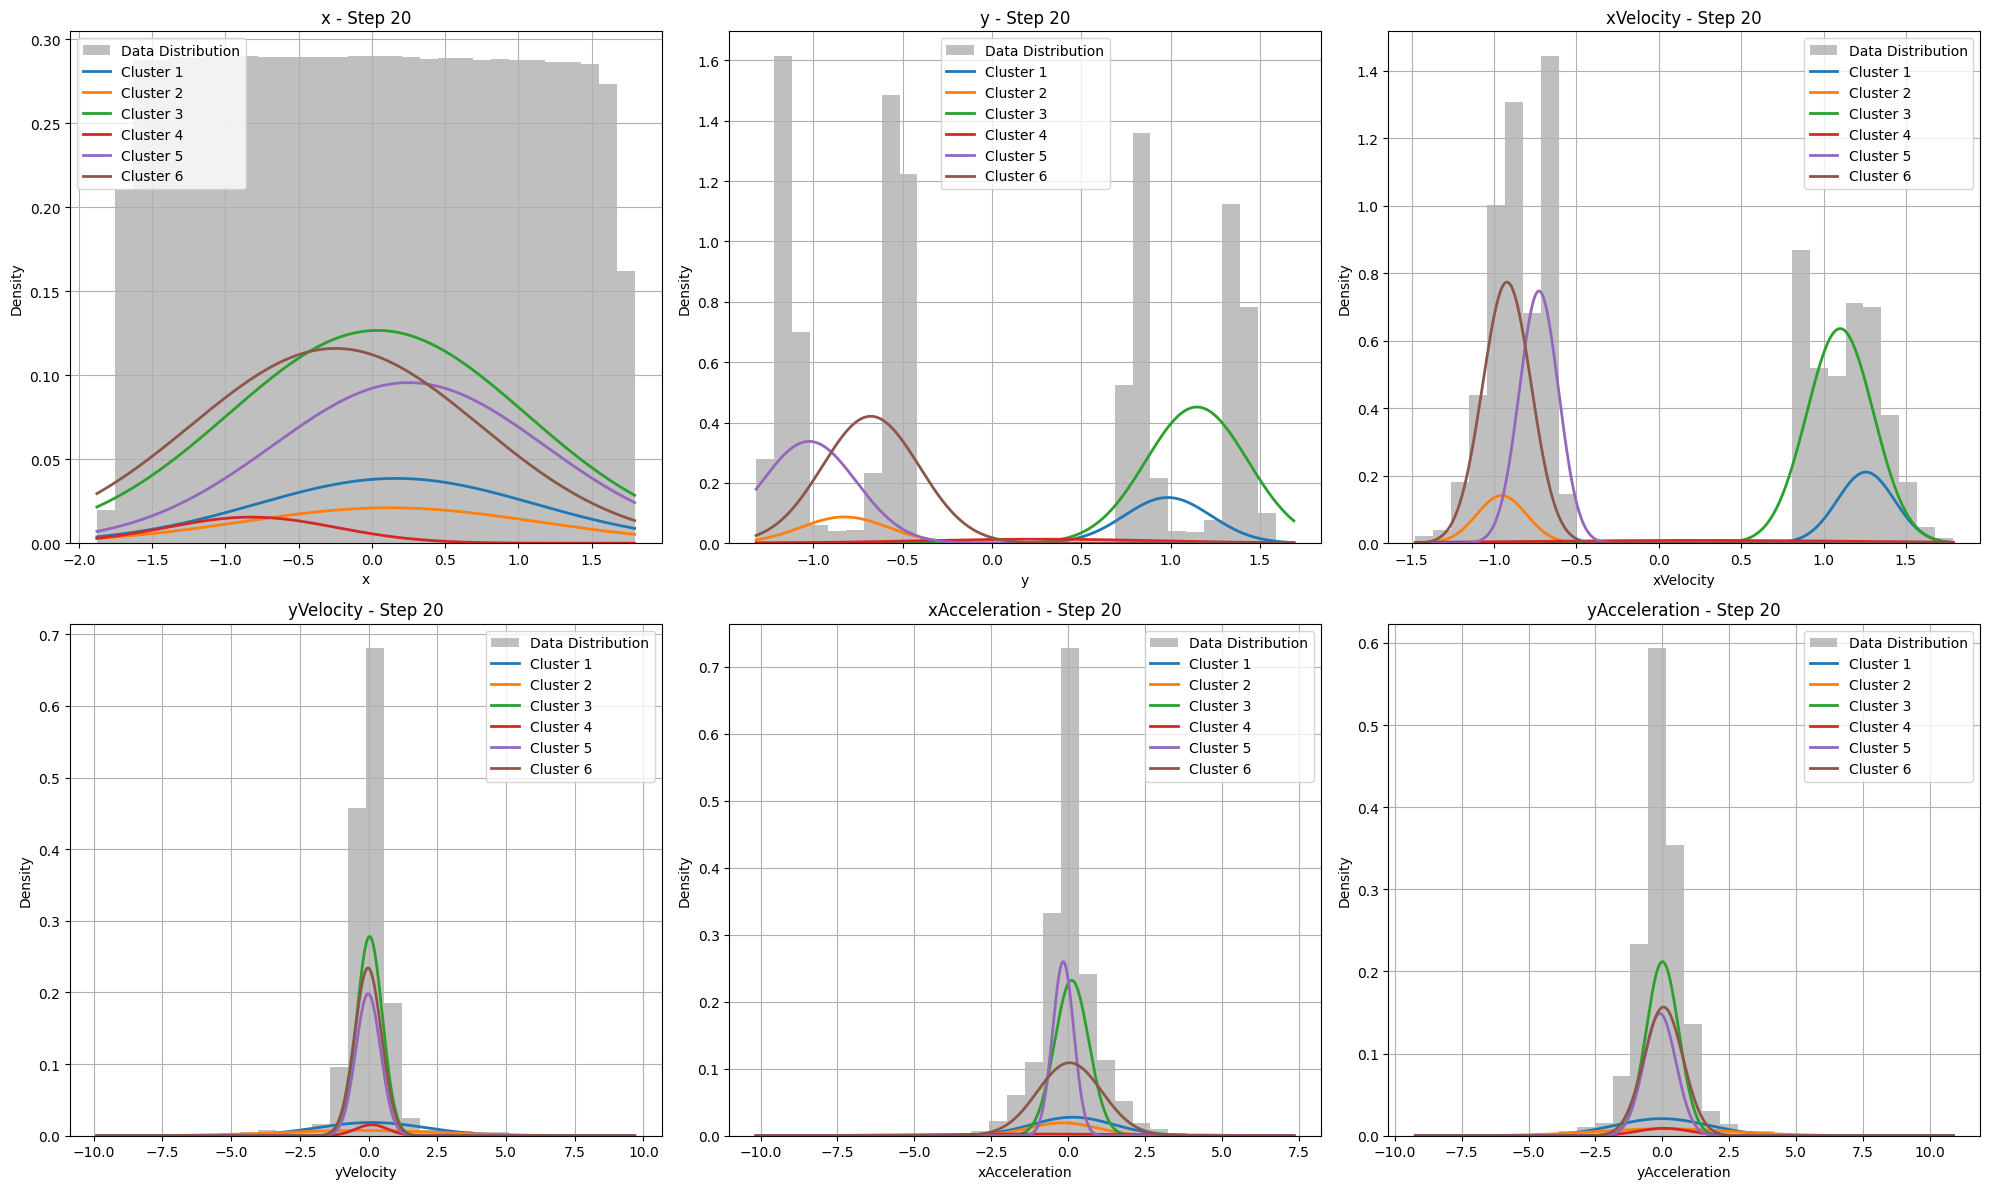

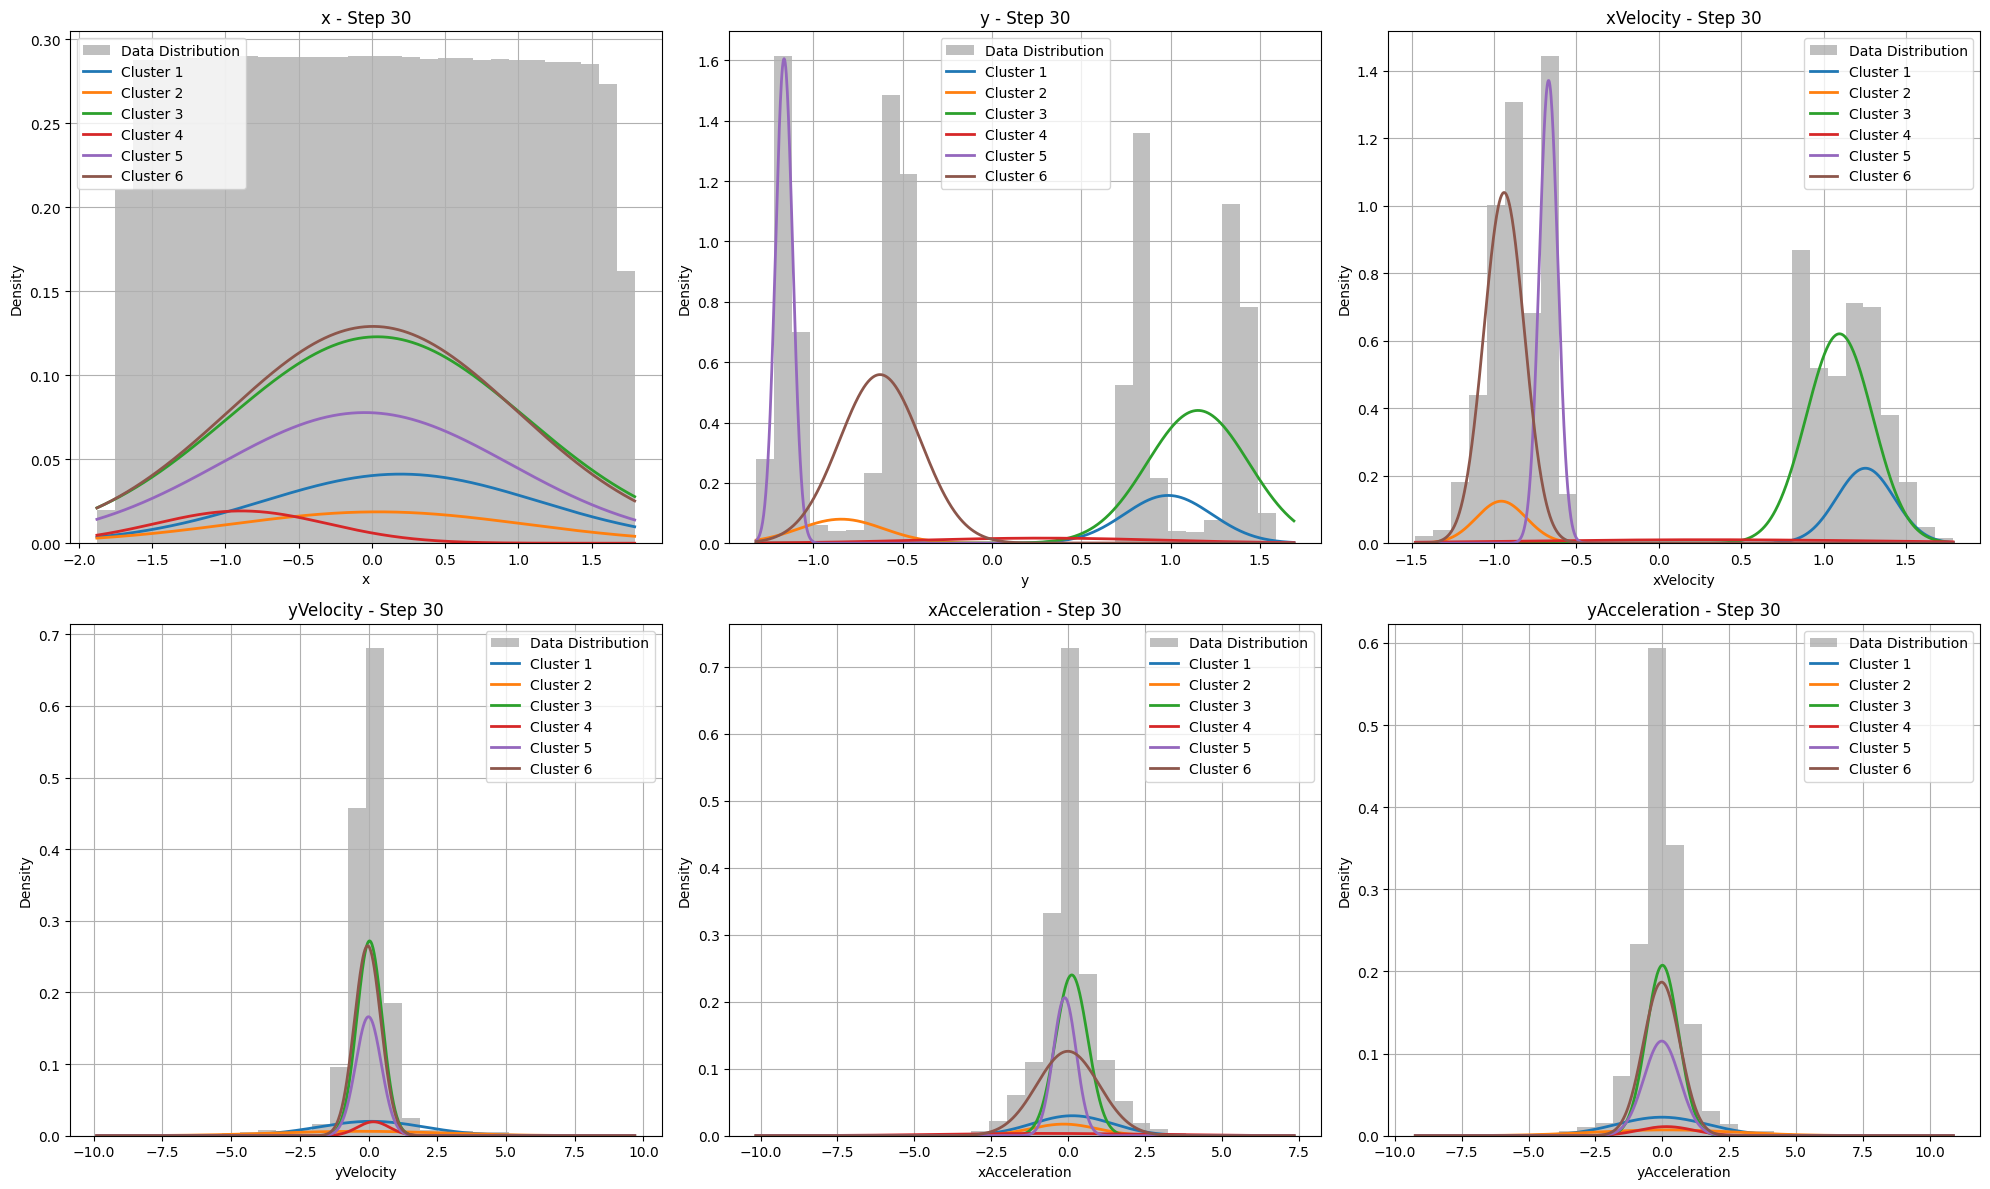

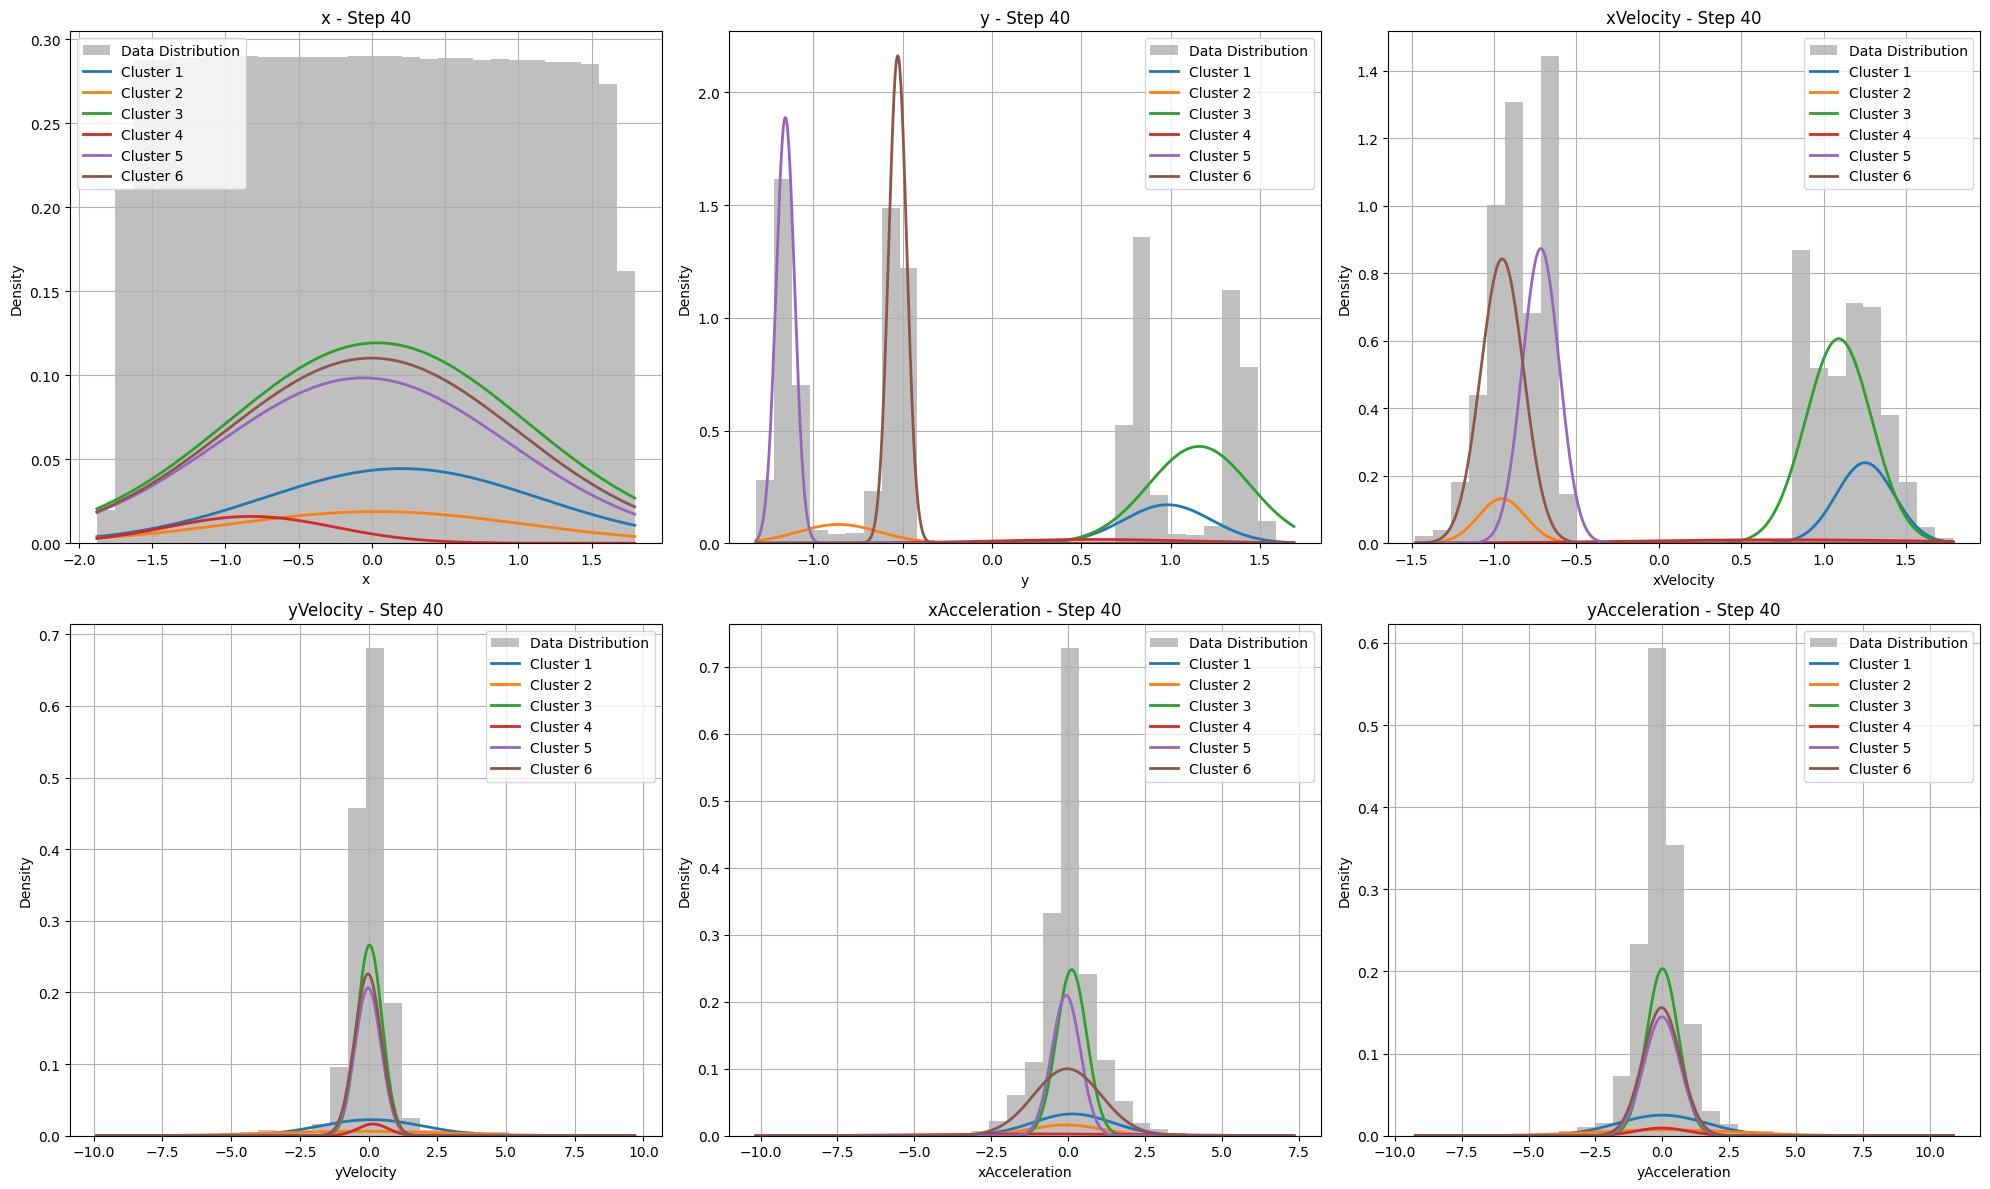

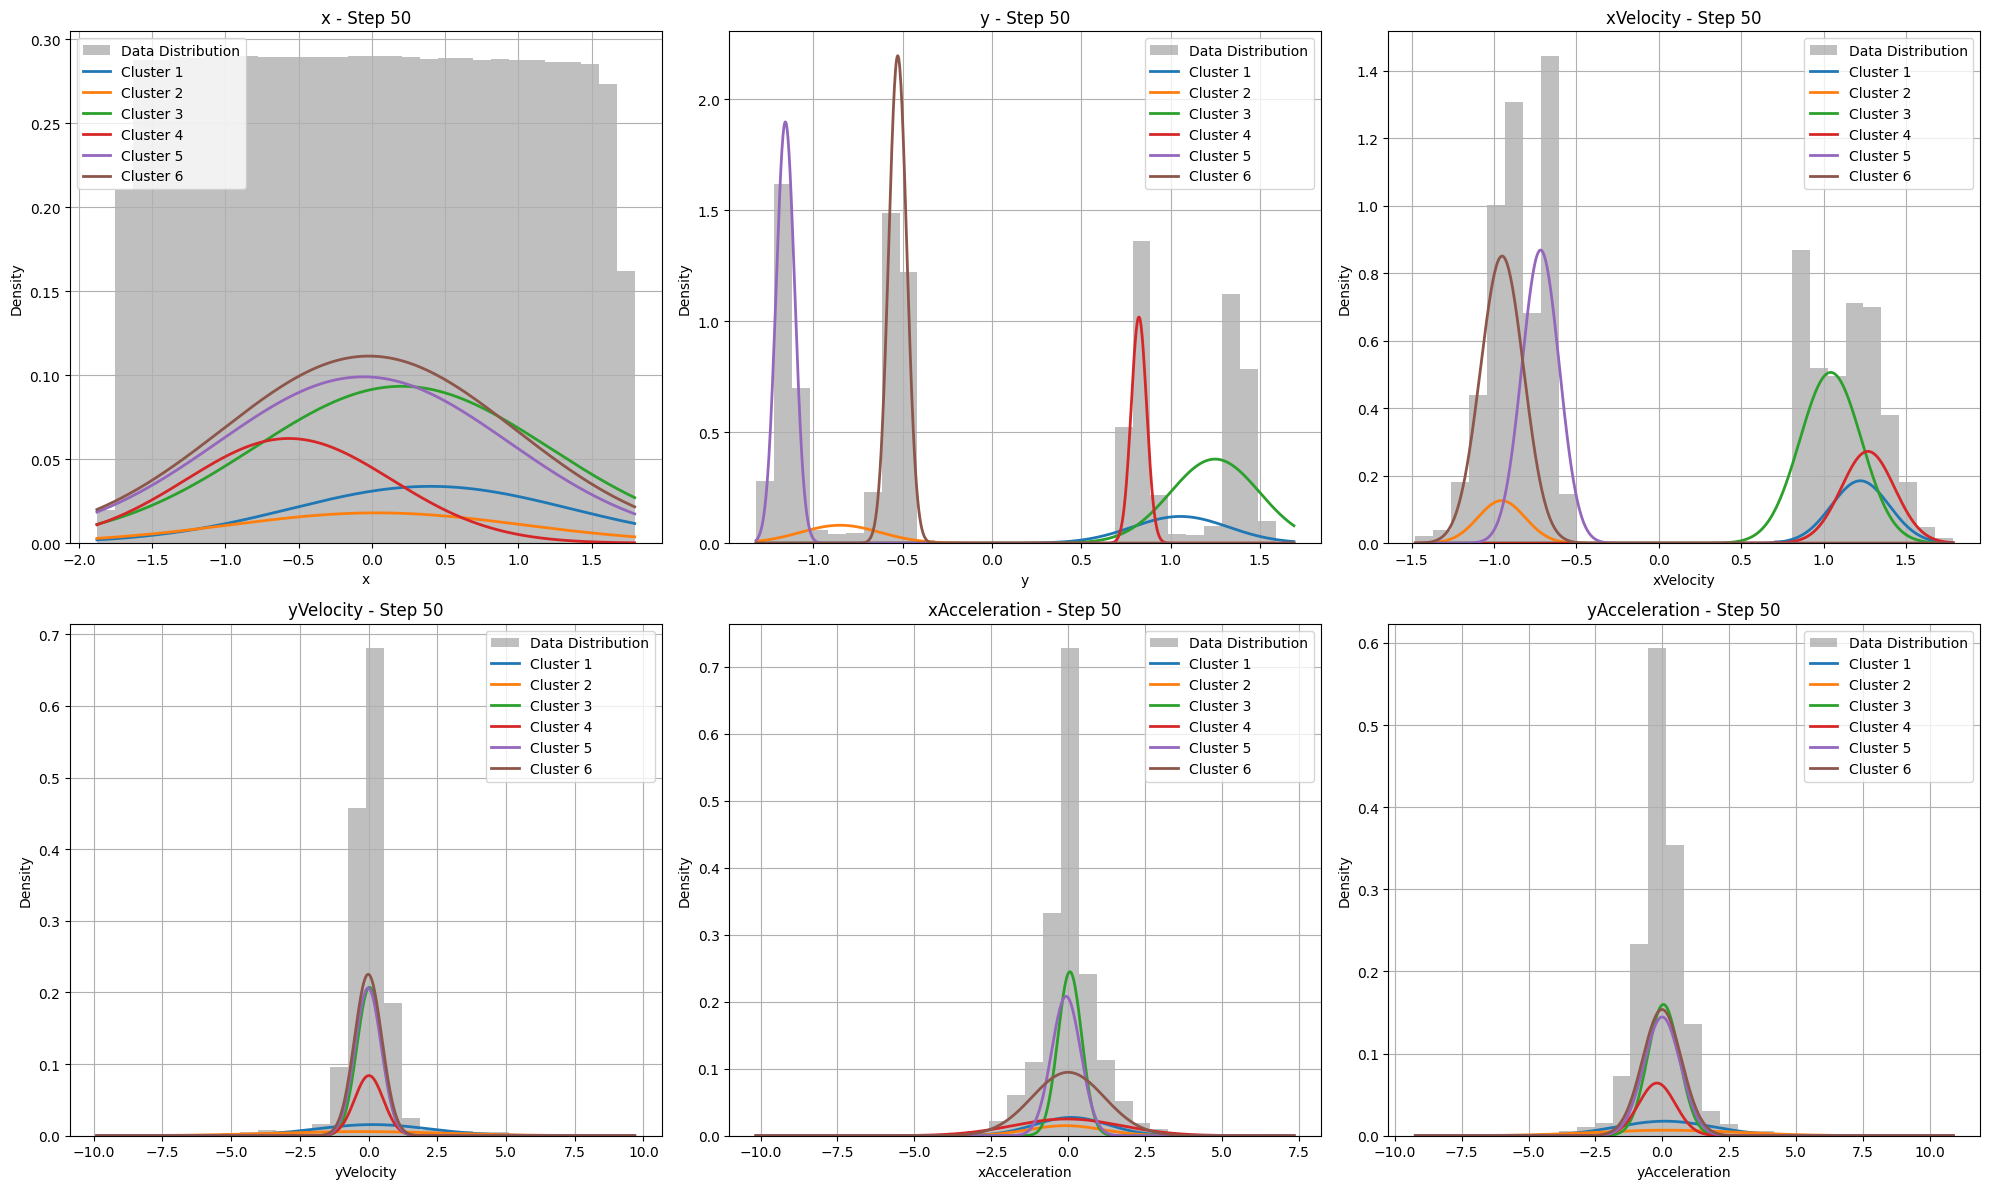

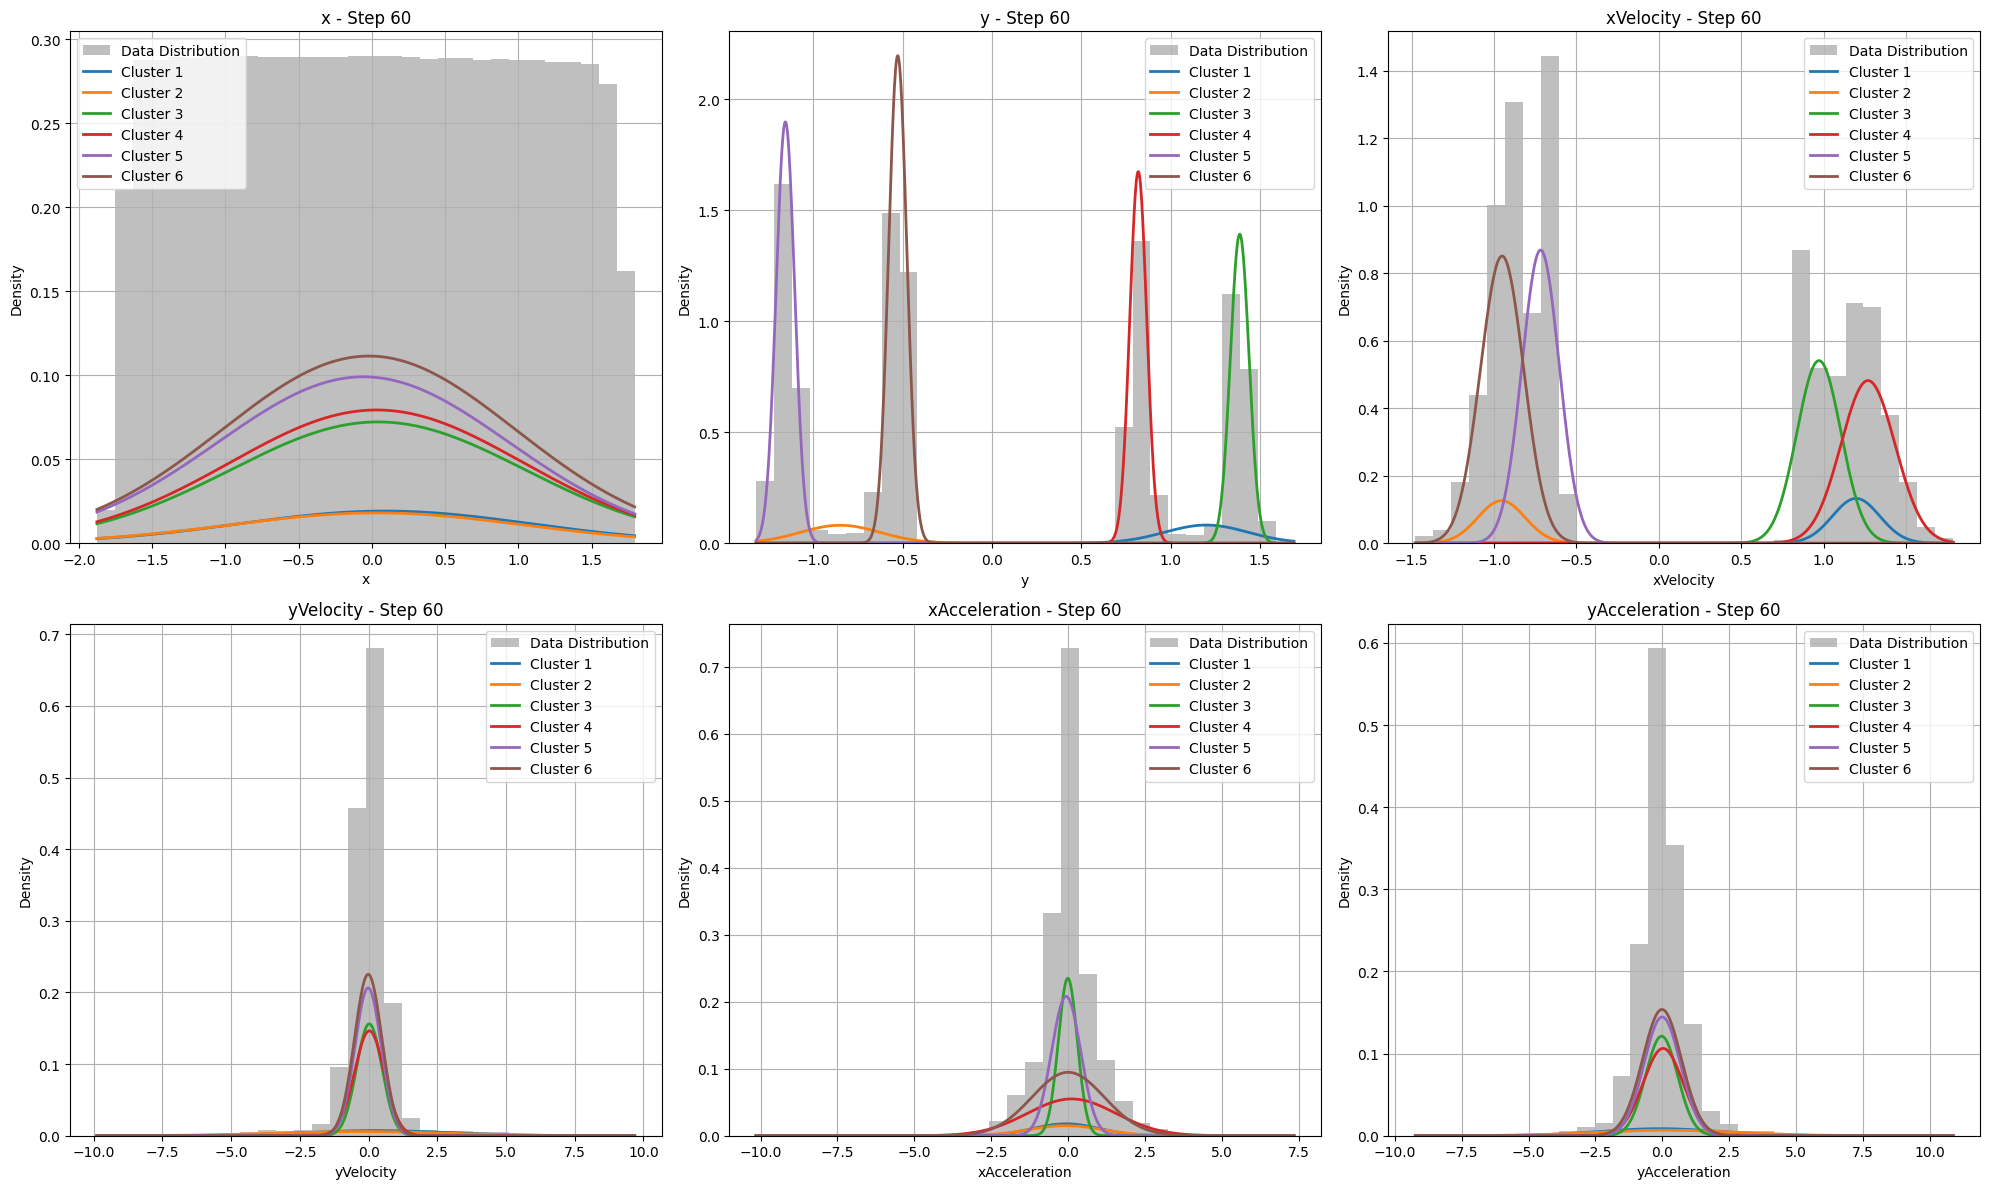

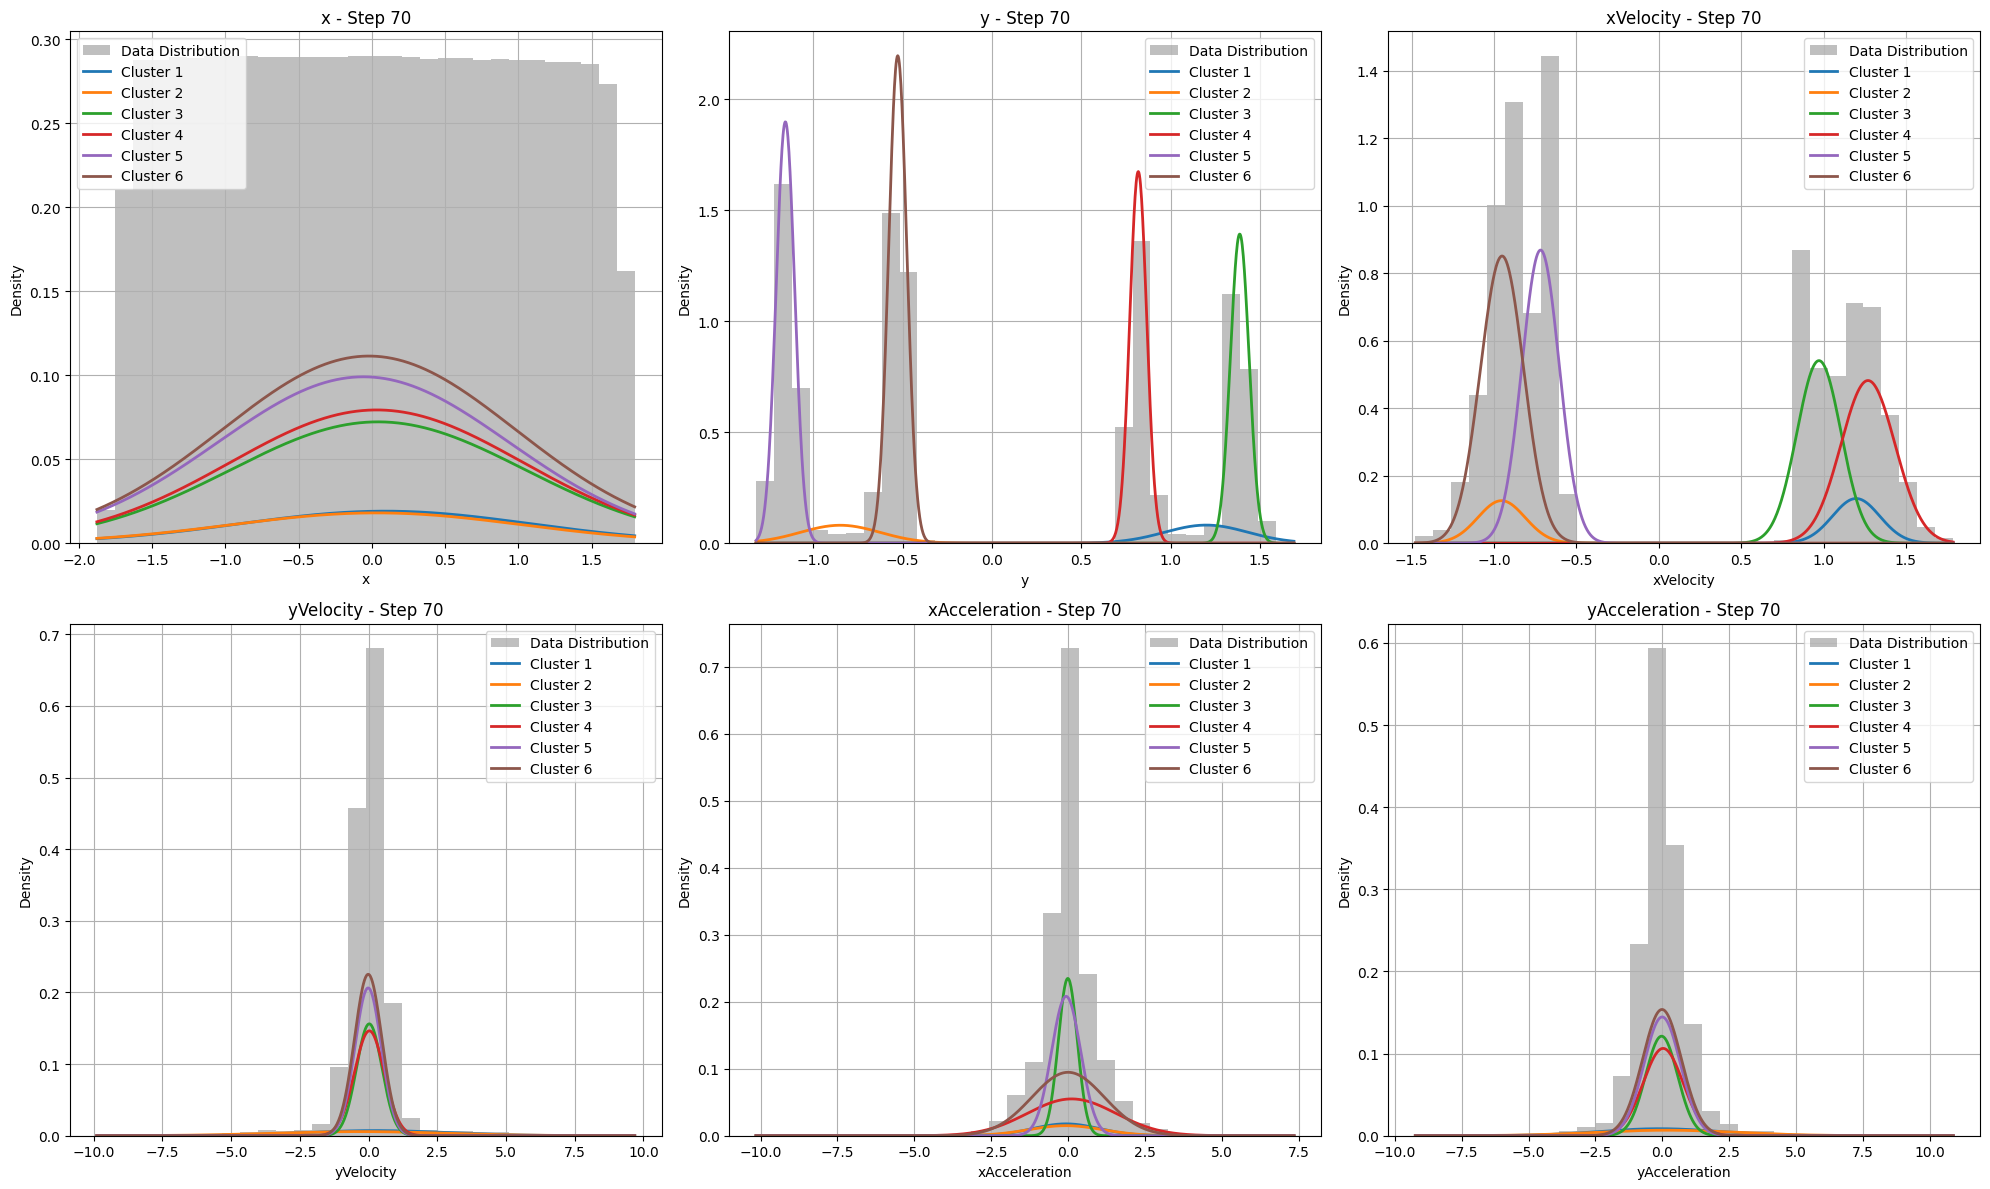

In [17]:
# Feature names (ensure they match the order in your dataset)
feature_names = ['x', 'y', 'xVelocity', 'yVelocity', 'xAcceleration', 'yAcceleration']

# Call the visualization function
visualize_all_feature_progressions(
    X,               # Standardized dataset
    means_list,      # List of means for each iteration
    covariances_list, # List of covariance matrices for each iteration
    weights_list,    # List of weights for each iteration
    saved_iterations, # Iterations to visualize (e.g., [1, 5, 10])
    feature_names    # Names of features
)


In [18]:
import seaborn as sns
import pandas as pd

def visualize_clusters_all_features(X, cluster_assignments, feature_names):
    """
    Visualizes three clusters using pairwise combinations of all six features.

    Parameters:
        X (numpy.ndarray): Standardized dataset (n_samples, n_features).
        cluster_assignments (numpy.ndarray): Cluster labels for each data point (n_samples,).
        feature_names (list): Names of the features for labeling the axes.
    """
    # Convert data to a Pandas DataFrame for easier plotting
    df = pd.DataFrame(X, columns=feature_names)
    df['Cluster'] = cluster_assignments  # Add cluster labels to the DataFrame

    # Use Seaborn's pairplot to visualize clusters
    pairplot = sns.pairplot(
        df,
        hue='Cluster',          # Color by cluster
        diag_kind="kde",        # Show kernel density estimate on the diagonal
        palette='Set2',         # Set color palette for clusters
        plot_kws={'alpha': 0.6, 's': 50},  # Scatterplot options
        diag_kws={'shade': True}  # KDE options
    )

    # Set plot title
    pairplot.fig.suptitle("Major Visualization: Clusters Across All Features", y=1.02)

    # Show the plot
    plt.show()


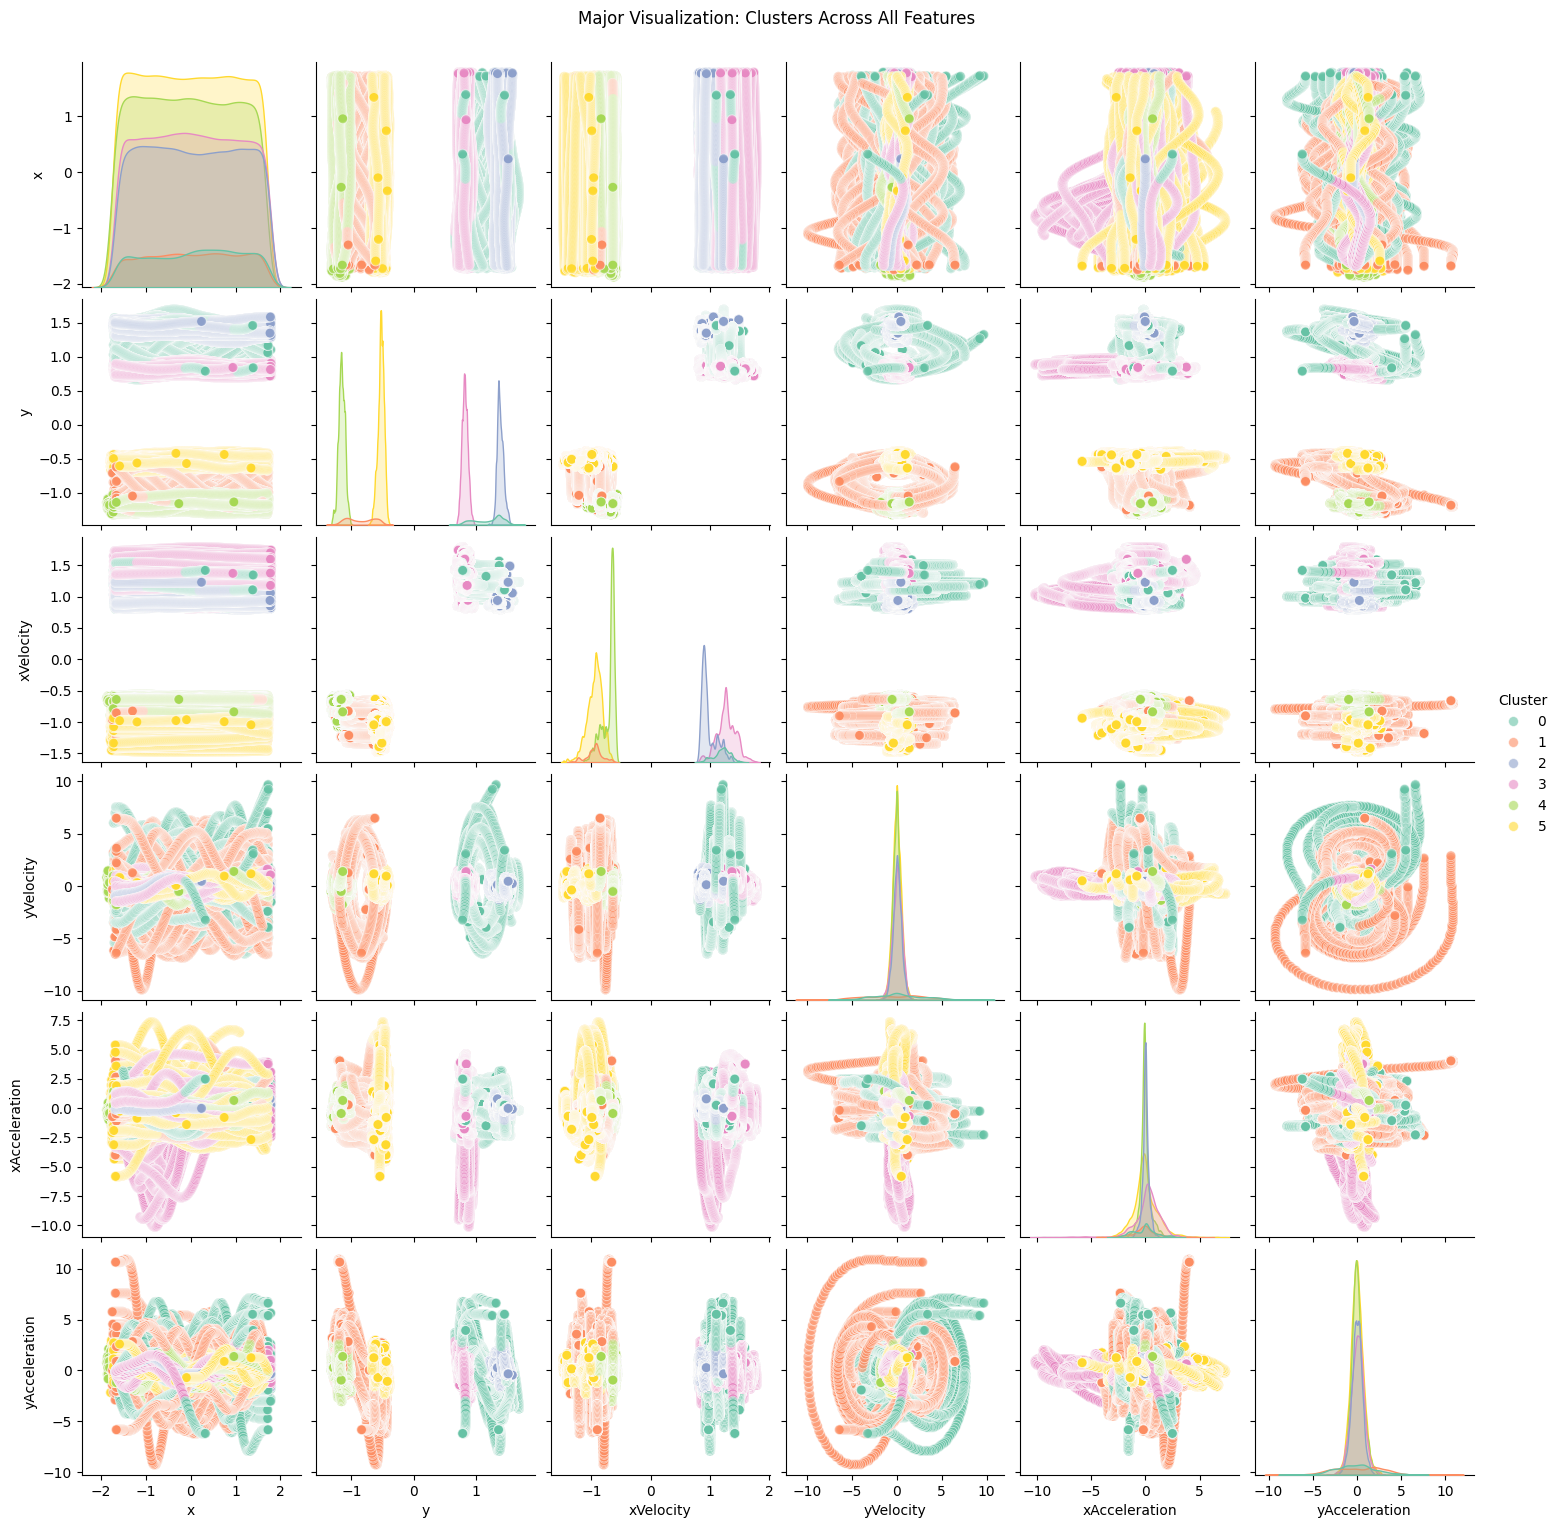

In [19]:
# Feature names
feature_names = ['x', 'y', 'xVelocity', 'yVelocity', 'xAcceleration', 'yAcceleration']

# Example cluster assignments (replace with your model's output)
cluster_assignments = final_responsibilities.argmax(axis=1)  # Assign clusters based on max responsibility

# Call the function
visualize_clusters_all_features(X, cluster_assignments, feature_names)


In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_pca_with_density(X, cluster_assignments, feature_names, num_clusters):
    """
    Performs PCA to reduce data to 2D, visualizes clusters, and overlays density for each feature.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        cluster_assignments (numpy.ndarray): Cluster labels for each data point (n_samples,).
        feature_names (list): Names of the features to label density plots.
        num_clusters (int): Number of clusters (e.g., 3).

    Returns:
        None
    """
    # Step 1: Reduce dimensionality to 2D using PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Step 2: Visualize PCA clusters
    plt.figure(figsize=(10, 8))
    for cluster in range(num_clusters):
        cluster_points = X_pca[cluster_assignments == cluster]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster + 1}", alpha=0.6)

    # Add labels and grid
    plt.title("Clusters Visualized in 2D with PCA")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.grid()
    plt.show()

    # Step 3: Visualize Density for Each Feature
    for feature_idx, feature_name in enumerate(feature_names):
        plt.figure(figsize=(10, 6))
        for cluster in range(num_clusters):
            cluster_points = X[cluster_assignments == cluster, feature_idx]
            sns.kdeplot(
                cluster_points, label=f"Cluster {cluster + 1}", fill=True, alpha=0.5
            )
        plt.title(f"Density Plot for {feature_name}")
        plt.xlabel(feature_name)
        plt.ylabel("Density")
        plt.legend()
        plt.grid()
        plt.show()


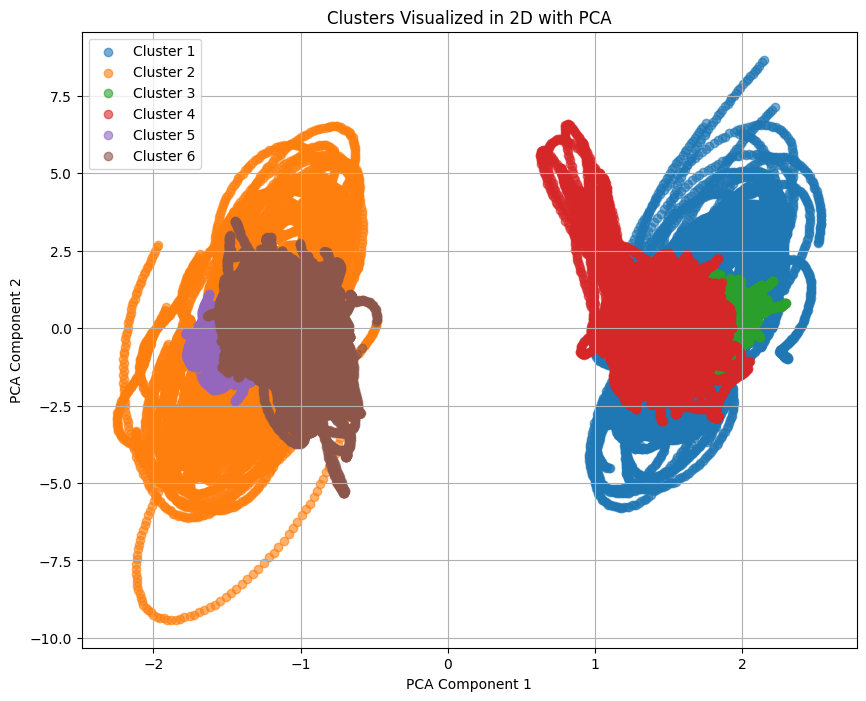

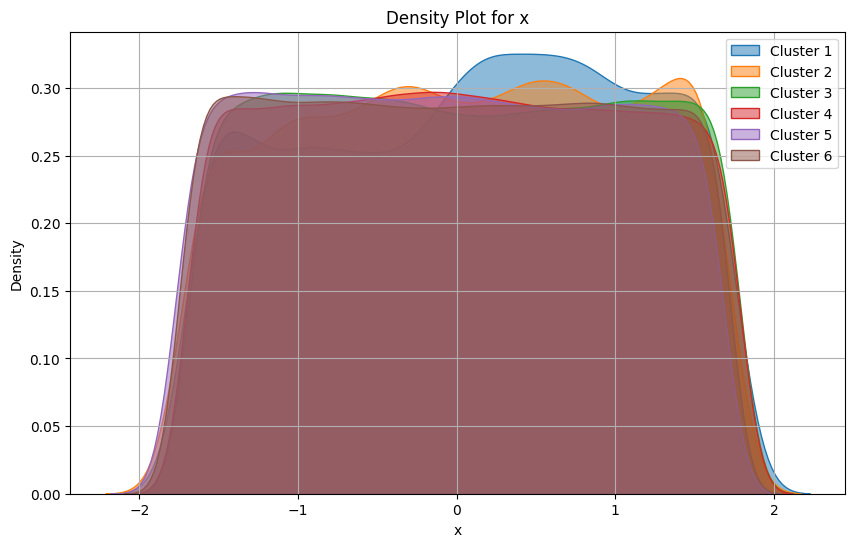

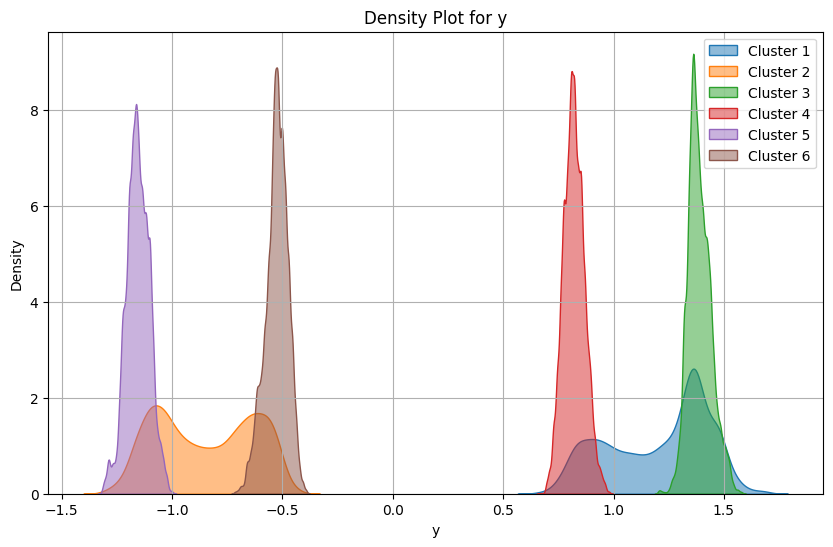

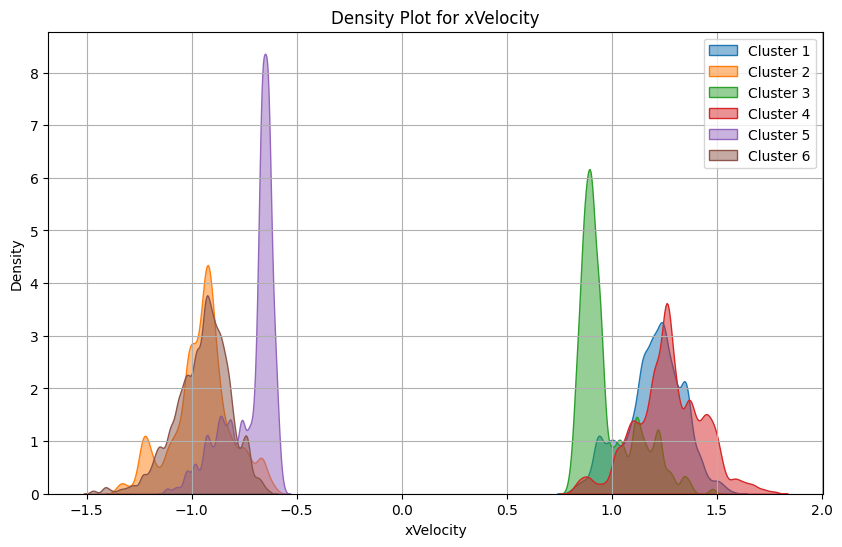

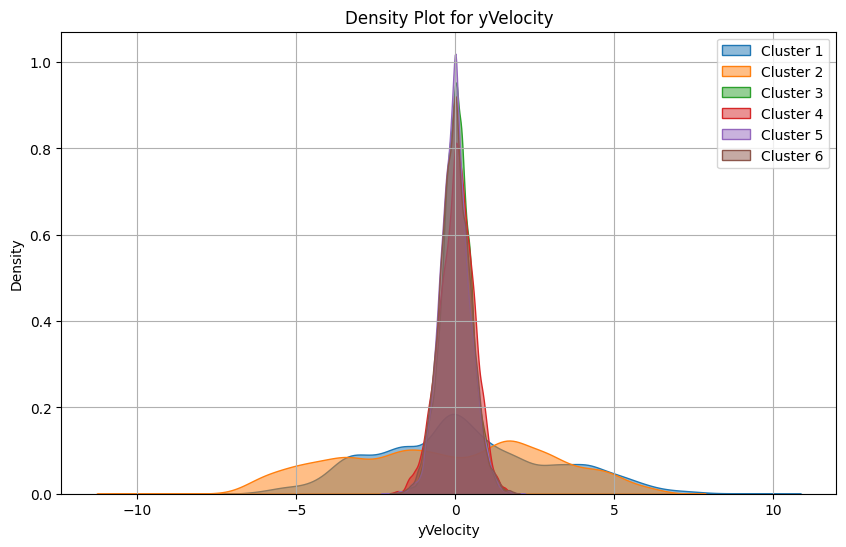

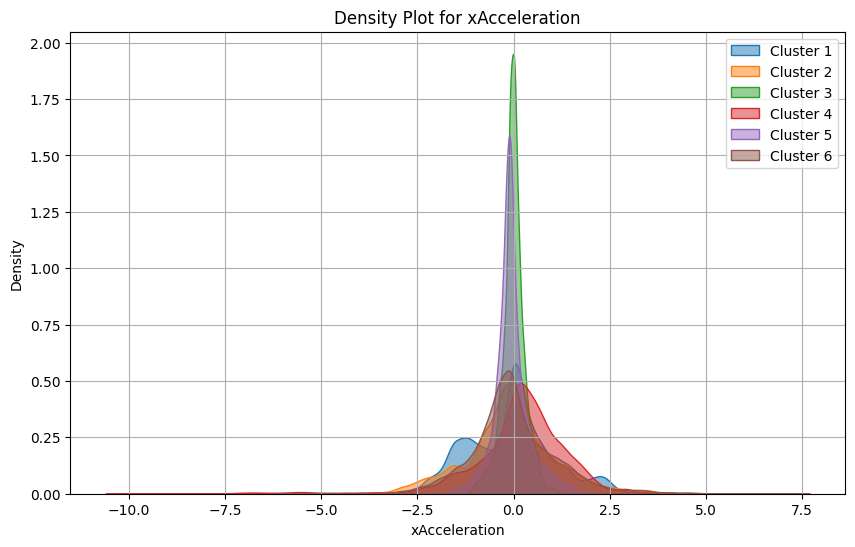

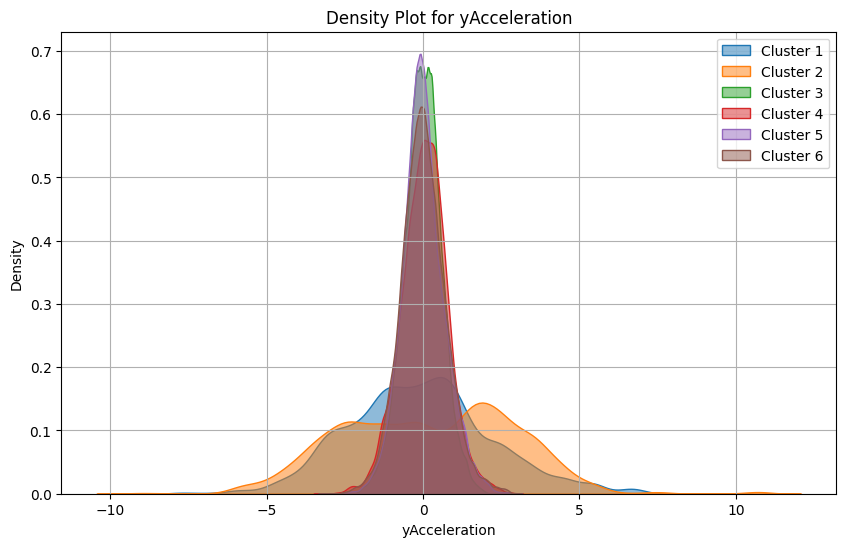

In [21]:
# Feature names (ensure they match your dataset order)
feature_names = ['x', 'y', 'xVelocity', 'yVelocity', 'xAcceleration', 'yAcceleration']

# Cluster assignments (from your GMM responsibilities)
cluster_assignments = final_responsibilities.argmax(axis=1)

# Number of clusters
num_clusters = 6

# Call the function
visualize_pca_with_density(X, cluster_assignments, feature_names, num_clusters)

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def visualize_pca_clusters(X, cluster_assignments, num_clusters):
    """
    Reduces six-dimensional data to two dimensions using PCA and visualizes clusters.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        cluster_assignments (numpy.ndarray): Cluster labels for each data point (n_samples,).
        num_clusters (int): Number of clusters (e.g., 3).

    Returns:
        None
    """
    # Step 1: Reduce dimensionality to 2D using PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Step 2: Plot the clusters in 2D
    plt.figure(figsize=(10, 8))
    for cluster in range(num_clusters):
        cluster_points = X_pca[cluster_assignments == cluster]
        plt.scatter(
            cluster_points[:, 0], cluster_points[:, 1], label=f"Cluster {cluster + 1}", alpha=0.6
        )

    # Add labels, legend, and grid
    plt.title("Clusters Visualized in 2D After PCA")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.grid()
    plt.show()


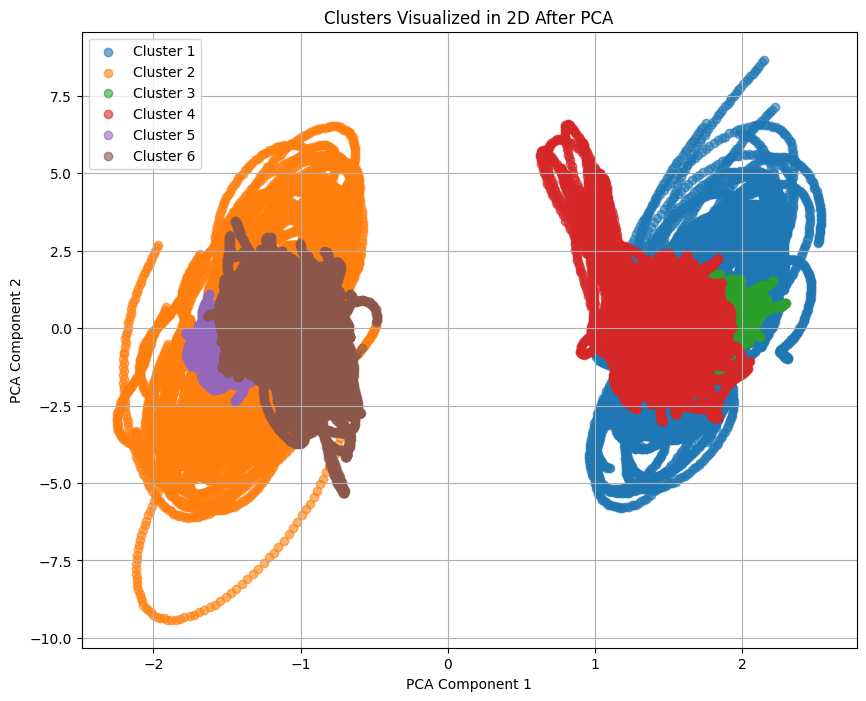

In [23]:
# Cluster assignments (from your GMM responsibilities)
cluster_assignments = final_responsibilities.argmax(axis=1)  # Assign clusters based on max responsibility


num_clusters = 6

# Call the PCA visualization function
visualize_pca_clusters(X, cluster_assignments, num_clusters)


In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA

def visualize_pca_gmm_progression(X, means_list, covariances_list, weights_list, saved_iterations):
    """
    Visualizes GMM clustering progression in 2D PCA space for specified iterations.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        weights_list (list): List of weights at specified iterations.
        saved_iterations (list): Iterations for which to visualize the clustering.

    Returns:
        None
    """
    # Step 1: Reduce the dataset to 2D using PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Step 2: Transform cluster means to PCA space
    means_pca_list = [pca.transform(means) for means in means_list]

    # Step 3: Transform covariances to PCA space
    covariances_pca_list = []
    for covariances in covariances_list:
        covariances_pca = []
        for cov in covariances:
            cov_pca = pca.components_ @ cov @ pca.components_.T
            covariances_pca.append(cov_pca)
        covariances_pca_list.append(covariances_pca)

    # Step 4: Plot progression for each iteration
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_pca_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue
        plt.figure(figsize=(8, 6))

        # Scatter plot of the PCA-transformed data points
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c='gray', alpha=0.5, s=10, label="Data Points")

        # Plot Gaussian distributions as ellipses
        for cluster_idx in range(len(means_pca_list[step_idx])):
            mean = means_pca_list[step_idx][cluster_idx]
            covariance = covariances_pca_list[step_idx][cluster_idx]

            # Plot the Gaussian as an ellipse
            plot_gaussian_ellipse(mean, covariance, label=f"Cluster {cluster_idx + 1}")

        plt.title(f"GMM Clustering at Iteration {iteration} (PCA-Reduced Space)")
        plt.xlabel("PCA Component 1")
        plt.ylabel("PCA Component 2")
        plt.legend()
        plt.grid()
        plt.show()


def plot_gaussian_ellipse(mean, cov, label=None):
    """
    Plots a Gaussian as an ellipse.

    Parameters:
        mean (numpy.ndarray): Mean of the Gaussian distribution (2D).
        cov (numpy.ndarray): Covariance matrix of the Gaussian distribution (2x2).
        label (str): Label for the cluster.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    # Width, height, and angle of the ellipse
    width, height = 2 * np.sqrt(eigenvalues)
    angle = np.arctan2(*eigenvectors[:, 0][::-1]) * (180 / np.pi)

    # Create the ellipse
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='black', facecolor='none', lw=2, label=label)
    plt.gca().add_patch(ellipse)


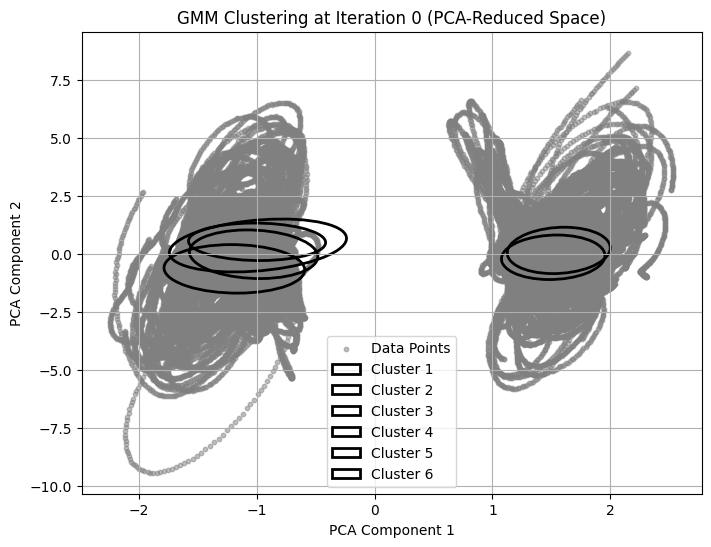

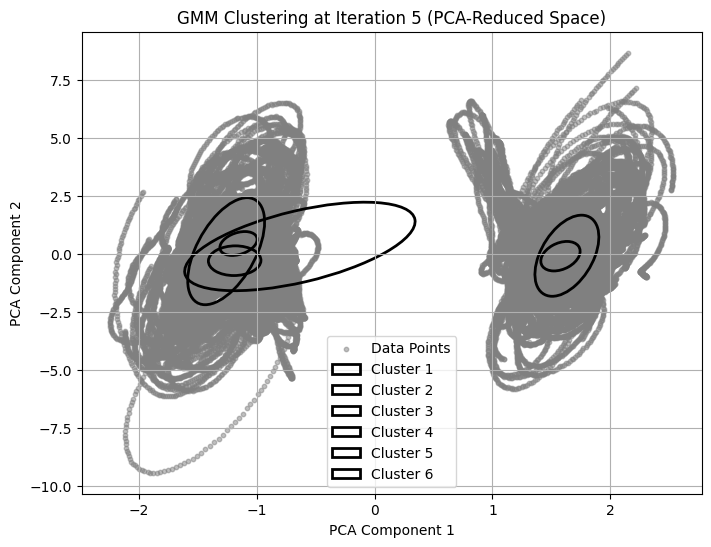

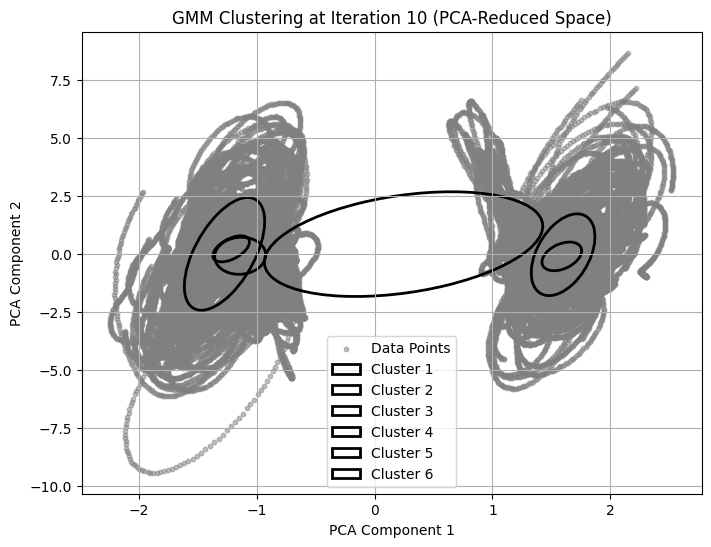

In [26]:


# Call the function
visualize_pca_gmm_progression(
    X,                # Standardized dataset
    means_list,       # List of means for each iteration
    covariances_list, # List of covariance matrices for each iteration
    weights_list,     # List of weights for each iteration
    saved_iterations  # Iterations to visualize
)


In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

def visualize_pca_gaussian_curves(X, means_list, covariances_list, saved_iterations):
    """
    Visualizes Gaussian bell-shaped curves for PCA components over iterations.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        saved_iterations (list): Iterations for which to visualize the clustering.

    Returns:
        None
    """
    # Step 1: Reduce the dataset to 2D using PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Transform means and covariances into PCA space
    means_pca_list = [pca.transform(means) for means in means_list]
    covariances_pca_list = []
    for covariances in covariances_list:
        covariances_pca = []
        for cov in covariances:
            cov_pca = pca.components_ @ cov @ pca.components_.T
            covariances_pca.append(cov_pca)
        covariances_pca_list.append(covariances_pca)

    # Step 2: Plot Gaussian bell-shaped curves iteratively
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_pca_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        plt.figure(figsize=(12, 8))

        # Generate a range of points for PCA components
        x_range = np.linspace(X_pca[:, 0].min(), X_pca[:, 0].max(), 500)
        y_range = np.linspace(X_pca[:, 1].min(), X_pca[:, 1].max(), 500)

        # Plot Gaussian bell-shaped curves for each cluster
        for cluster_idx in range(len(means_pca_list[step_idx])):
            mean = means_pca_list[step_idx][cluster_idx]
            covariance = covariances_pca_list[step_idx][cluster_idx]
            variance_x, variance_y = np.diag(covariance)  # Variance for PCA1 and PCA2

            # Gaussian curve for PCA Component 1
            gaussian_curve_x = (1 / np.sqrt(2 * np.pi * variance_x)) * np.exp(
                -0.5 * ((x_range - mean[0]) ** 2) / variance_x
            )
            plt.plot(x_range, gaussian_curve_x, label=f"Cluster {cluster_idx + 1} - PCA1", lw=2)

            # Gaussian curve for PCA Component 2
            gaussian_curve_y = (1 / np.sqrt(2 * np.pi * variance_y)) * np.exp(
                -0.5 * ((y_range - mean[1]) ** 2) / variance_y
            )
            plt.plot(y_range, gaussian_curve_y, linestyle="--", label=f"Cluster {cluster_idx + 1} - PCA2", lw=2)

        # Add title and labels
        plt.title(f"Gaussian Bell-Shaped Curves for PCA Components at Iteration {iteration}")
        plt.xlabel("PCA Components")
        plt.ylabel("Probability Density")
        plt.legend()
        plt.grid()
        plt.show()




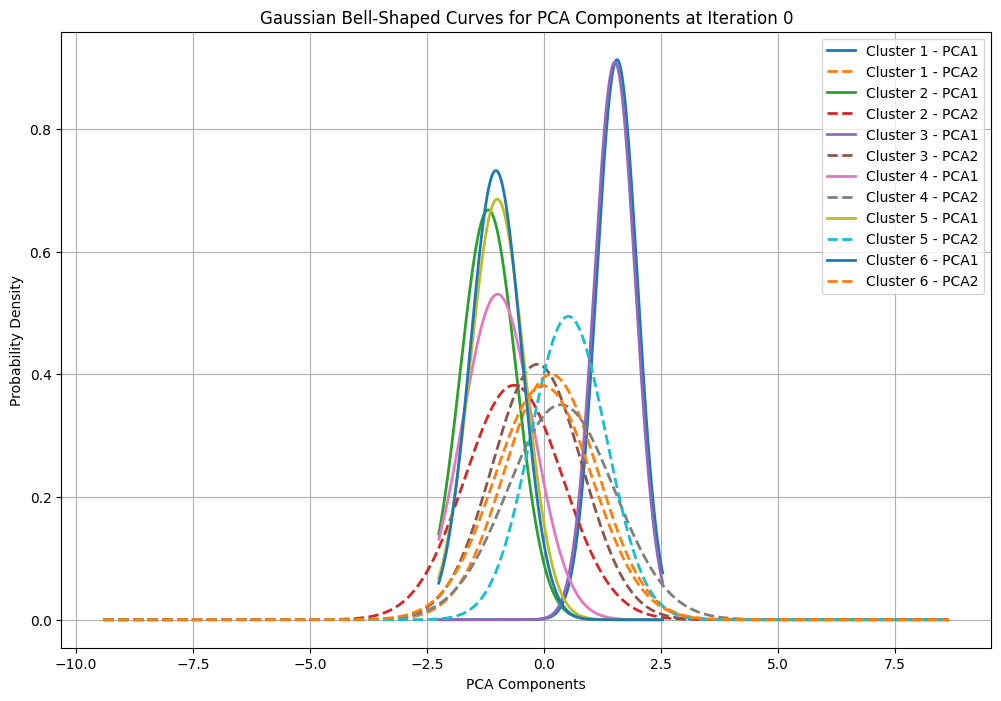

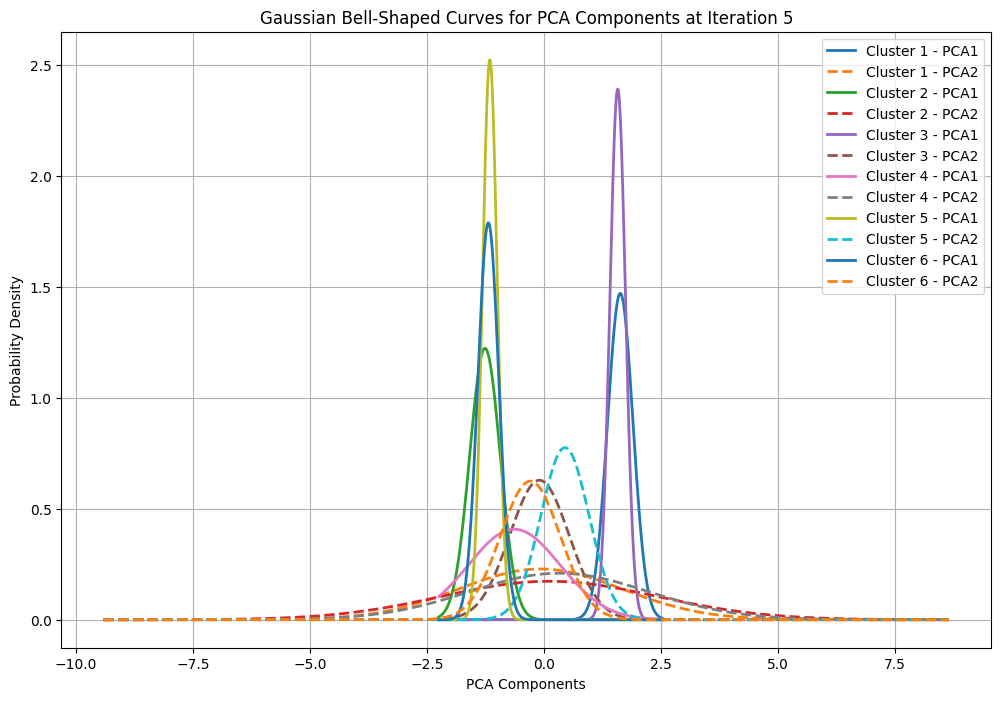

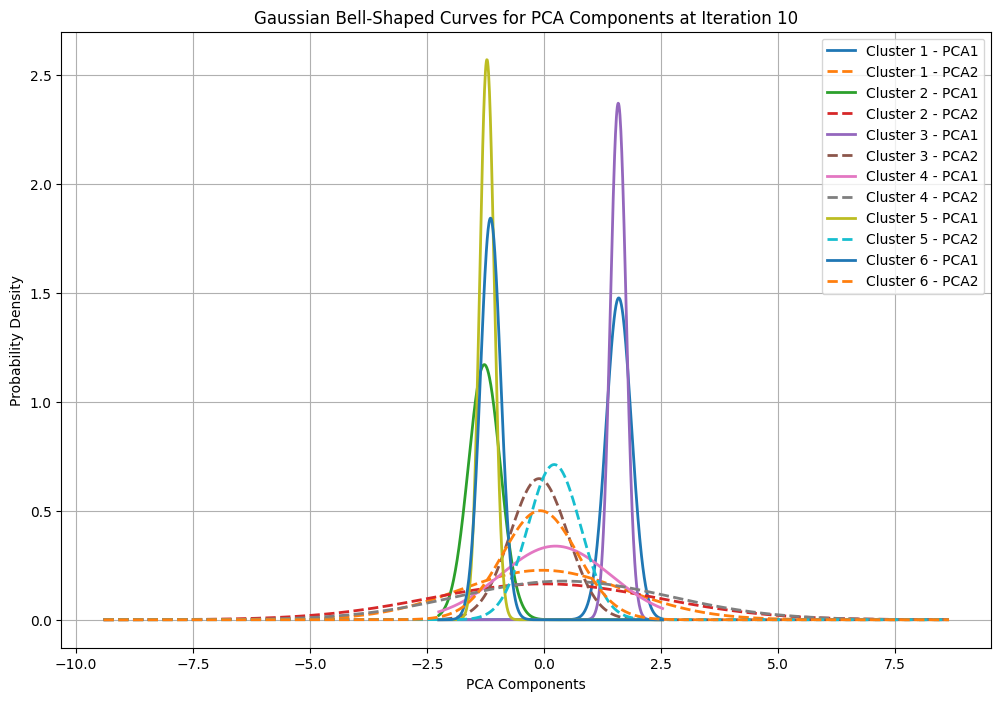

In [42]:



# Call the function
visualize_pca_gaussian_curves(
    X,                # Standardized dataset
    means_list,       # List of means for each iteration
    covariances_list, # List of covariance matrices for each iteration
    saved_iterations  # Iterations to visualize
)



In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_combined_feature_bell_curve(X, means_list, covariances_list, saved_iterations):
    """
    Combines multiple features into one and visualizes Gaussian bell-shaped curves for the combined feature.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        saved_iterations (list): Iterations for which to visualize the clustering.

    Returns:
        None
    """
    # Step 1: Combine features into a single feature (e.g., sum of all features)
    combined_feature = X.sum(axis=1)  # You can replace this with another aggregation method

    # Step 2: Plot Gaussian bell-shaped curves iteratively
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        plt.figure(figsize=(10, 6))

        # Generate a range of values for the combined feature
        x_range = np.linspace(combined_feature.min(), combined_feature.max(), 500)

        # Plot Gaussian bell-shaped curves for each cluster
        for cluster_idx in range(len(means_list[step_idx])):
            # Compute the mean and variance for the combined feature
            mean_combined = means_list[step_idx][cluster_idx].sum()
            variance_combined = np.diag(covariances_list[step_idx][cluster_idx]).sum()

            # Compute Gaussian PDF
            gaussian_pdf = norm.pdf(x_range, loc=mean_combined, scale=np.sqrt(variance_combined))
            plt.plot(x_range, gaussian_pdf, label=f"Cluster {cluster_idx + 1}", lw=2)

        # Add title and labels
        plt.title(f"Gaussian Bell-Shaped Curve for Combined Feature at Iteration {iteration}")
        plt.xlabel("Combined Feature")
        plt.ylabel("Probability Density")
        plt.legend()
        plt.grid()
        plt.show()


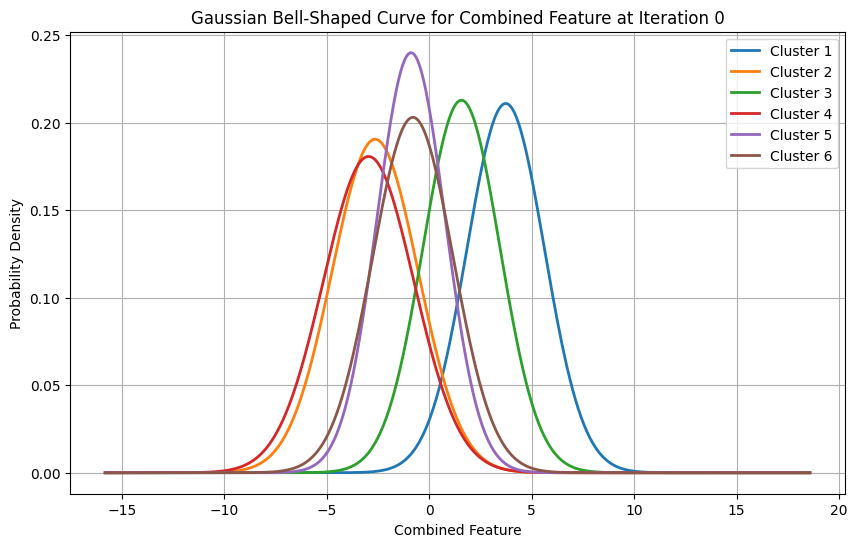

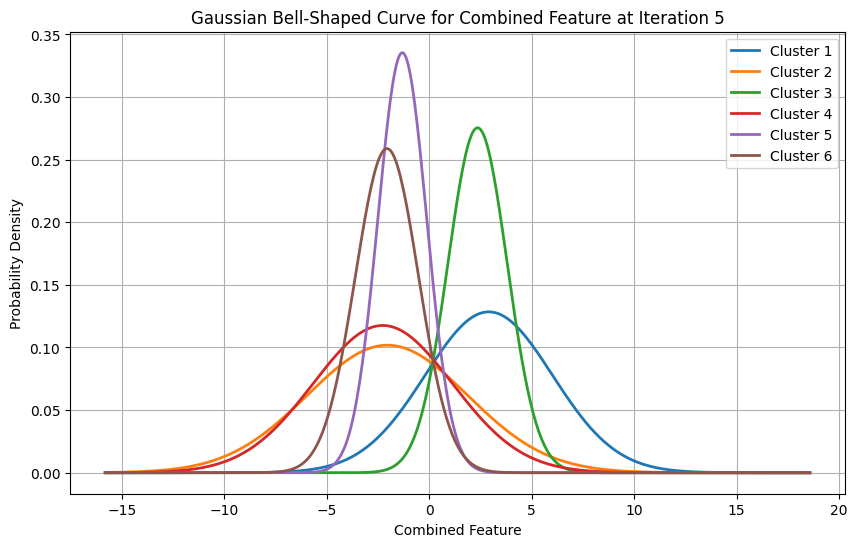

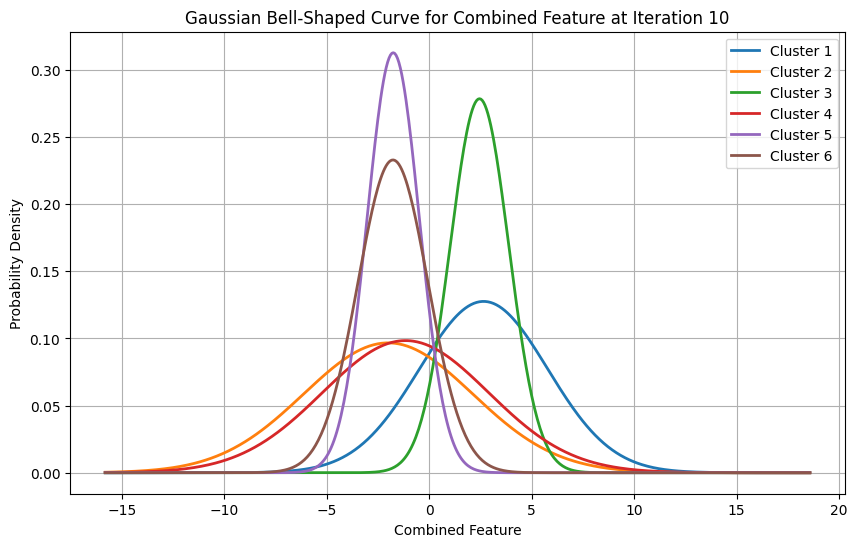

In [47]:


# Call the function
visualize_combined_feature_bell_curve(
    X,                # Standardized dataset
    means_list,       # List of means for each iteration
    covariances_list, # List of covariance matrices for each iteration
    saved_iterations  # Iterations to visualize
)
